
**Title:** `Renewable Energy Forecasting`   
    
**Description:** `This notebook reproduces all empirical results presented in the thesis.`    


## 1. Library Installation (If Required)

This cell installs required Python libraries used for forecasting, statistical analysis, machine learning, and deep learning. It ensures that all dependencies are available before executing the modeling pipeline.

In [338]:
# ==========================================
# Install Required External Libraries
# Run this cell only if packages are missing
# ==========================================

!pip install numpy pandas matplotlib seaborn
!pip install scikit-learn
!pip install statsmodels scipy
!pip install tensorflow
!pip install xgboost
!pip install prophet
!pip install joblib

## 2. Import Required Libraries

This cell imports all necessary libraries, including pandas, numpy, statsmodels, Prophet, XGBoost, TensorFlow/Keras, sklearn, and visualization libraries. These packages support data processing, model implementation, and evaluation.

In [1]:
# =========================
# Core Libraries
# =========================
import os
import random
import warnings
from math import sqrt

import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Machine Learning Metrics
# =========================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# =========================
# Statistical Models
# =========================
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import breaks_cusumolsresid, acorr_ljungbox

# =========================
# Deep Learning (LSTM)
# =========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# Gradient Boosting
# =========================
from xgboost import XGBRegressor

# =========================
# Prophet
# =========================
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

# =========================
# Utilities
# =========================
from pandas.api.types import is_numeric_dtype
import joblib
from scipy import stats

warnings.filterwarnings("ignore")

## Clean Final Modeling Pipeline & Evaluation Utilities

This cell initializes the final consolidated forecasting pipeline used in the study. It establishes a structured modeling framework that includes:

- Prophet (decomposition-based model)
- SARIMAX (classical statistical model)
- XGBoost (machine learning model)
- LSTM (deep learning model)

A reference path to the project document is defined for reproducibility, and required library dependencies are noted.

In addition, custom evaluation functions are implemented to ensure consistent performance assessment across all models. The following metrics are defined:

- Mean Absolute Percentage Error (MAPE)
- Symmetric Mean Absolute Percentage Error (SMAPE)
- A unified evaluation function (`eval_metrics`) returning:
  - RMSE
  - MAE
  - MAPE
  - SMAPE
  - R²

These utilities standardize model comparison and ensure that all forecasting approaches are evaluated under an identical accuracy framework.

In [2]:
# Clean final modelling pipeline: Prophet, SARIMAX, XGBoost, LSTM (optional)
# Reference uploaded project file (local path):
PROJECT_PDF_PATH = "/mnt/data/big_data_analysis_project.pdf"

# Requirements (example):
# pip install pandas numpy matplotlib seaborn scikit-learn xgboost statsmodels prophet tensorflow joblib


warnings.filterwarnings("ignore")



# -------------------------
# Utility metrics
# -------------------------
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask]-y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.nan

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    return 100*np.mean(2.0 * np.abs(y_pred[mask]-y_true[mask]) / denom[mask]) if mask.any() else np.nan

def eval_metrics(y_true, y_pred):
    return {
        "RMSE": sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE (%)": mape(y_true, y_pred),
        "SMAPE (%)": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


## 1. Paths and Global Configuration

This section defines the core file paths and configuration settings used throughout the forecasting workflow.

### Dataset Path
`DATA_PATH` specifies the location of the cleaned and aggregated time series dataset.  
The dataset is expected to contain **one observation per month**, representing the total renewable energy generation.

### Target Variable
`TARGET_COL` defines the dependent variable used for forecasting.  
This must exactly match the column name in the dataset to avoid runtime errors.

### Model Storage Directory
`MODELS_DIR` defines the directory where trained models will be saved.  
If the directory does not already exist, it is automatically created to ensure reproducibility and organized model management.

This structure improves:
- Reproducibility
- Portability of the notebook
- Clean separation between data and model artifacts

In [3]:

# -------------------------
# Paths & settings (edit if needed)
# -------------------------
DATA_PATH = "datasets/clean_us_agg.csv"   # cleaned aggregated series (one row per month)
TARGET_COL = "Total Renewable Energy"     # Ensure this matches your CSV column name
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

## 2. Data Loading and Preprocessing

This section loads the cleaned and aggregated renewable energy dataset and prepares it for time series forecasting.

### Data Import
The dataset is loaded from the predefined `DATA_PATH`.  
- The first column is treated as the time index.
- Dates are parsed automatically.
- The index is renamed to **"Date"** for clarity.
- The dataset is sorted chronologically to ensure proper time ordering.

Basic dataset diagnostics are printed:
- Dataset shape (rows × columns)
- Time range (start date → end date)

### Target Variable Validation
Before proceeding, the script verifies that the selected target column (`TARGET_COL`) exists in the dataset.  
If not, execution is stopped to prevent downstream modeling errors.

### Time Series Preparation
The selected target variable is:

- Converted to **monthly start frequency (`MS`)**
- Interpolated to handle missing values
- Forward-filled and backward-filled to ensure continuity

Ensuring a continuous, equally spaced time series is critical for:
- SARIMAX modeling
- LSTM training
- Prophet forecasting
- XGBoost lag feature creation

This preprocessing step guarantees that the series is structurally consistent and ready for forecasting.

In [4]:
# -------------------------
# 1. Load data
# -------------------------
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df.index.name = "Date"
df = df.sort_index()
print("Loaded:", DATA_PATH, "shape:", df.shape)
print("Index range:", df.index.min(), "->", df.index.max())

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Columns: {df.columns.tolist()}")

series = df[TARGET_COL].asfreq('MS')  # monthly start frequency
series = series.interpolate().fillna(method='ffill').fillna(method='bfill')


Loaded: datasets/clean_us_agg.csv shape: (613, 14)
Index range: 1973-01-01 00:00:00 -> 2024-01-01 00:00:00


## 3. Train–Test Split Strategy

To evaluate forecasting performance objectively, the time series is divided into training and test sets using a chronological split.

### Test Horizon
A fixed forecasting horizon of **36 months** is reserved as the test set.  
This allows for medium-term forecast evaluation and reflects realistic forecasting scenarios in energy planning.

### Training Set
The training data includes all observations from the beginning of the series up to:

\[
\text{Last Date} - 36 \text{ months}
\]

This subset is used to:
- Fit SARIMAX models  
- Train LSTM networks  
- Train XGBoost regressors  
- Fit Prophet models  

### Test Set
The test set consists of the final 36 months of data.  
It is strictly held out during model training and used exclusively for out-of-sample evaluation.

### Why Chronological Splitting?

Unlike random train-test splits used in standard machine learning, time series data must preserve temporal order.  
Shuffling would introduce data leakage and invalidate forecasting results.

This approach ensures:
- No future information leaks into training
- Realistic forecast evaluation
- Comparable performance across different models

In [5]:

# -------------------------
# 2. Train/validation/test split
# -------------------------
# adjust test_horizon as you like
test_horizon = 36  # months reserved as test set
train_end = series.index[-1] - pd.DateOffset(months=test_horizon)
train = series[:train_end]
test = series[train_end + pd.DateOffset(months=1):]

print("Train:", train.index.min(), "->", train.index.max(), "(", len(train), "months )")
print("Test :", test.index.min(), "->", test.index.max(), "(", len(test), "months )")


Train: 1973-01-01 00:00:00 -> 2021-01-01 00:00:00 ( 577 months )
Test : 2021-02-01 00:00:00 -> 2024-01-01 00:00:00 ( 36 months )


## 4. Feature Engineering for Machine Learning and Deep Learning Models

To enable supervised learning models such as XGBoost and LSTM, the univariate time series is transformed into a structured feature matrix.

Unlike classical models (e.g., SARIMAX or Prophet), machine learning models require explicit input features to capture temporal dependencies.

---

### 4.1 Lag Features

Lag variables are created to represent past observations of the target variable:

- `lag_1` → Previous month
- `lag_12` → Same month in previous year (seasonality)
- `lag_24` → Two years prior

Lag features allow models to learn autoregressive patterns.

---

### 4.2 Rolling Mean Features

Rolling averages are computed over multiple windows:

- 3-month rolling mean → short-term smoothing
- 12-month rolling mean → annual trend
- 36-month rolling mean → long-term structural trend

Rolling features help capture trend strength and reduce noise sensitivity.

To avoid data leakage, rolling statistics are shifted by one period.

---

### 4.3 Time-Based Features

Additional temporal features include:

- `time_idx` → Linear time progression index
- Monthly dummy variables → Explicit seasonal encoding

Month dummies allow models to capture intra-year seasonal patterns without assuming fixed sinusoidal structure.

---

### 4.4 Handling Missing Values

Lag creation introduces missing values at the beginning of the dataset.  
These rows are removed to ensure a clean feature matrix.

---

### 4.5 Alignment with Time Index

Since lag and rolling features reduce the dataset length, the feature dataframe index is realigned with the corresponding timestamps of the original series.

This ensures:
- Correct chronological ordering
- Accurate train–test splitting
- No misalignment between predictors and target

---

### 4.6 Final Dataset Structure

The dataset is split into:

- `X_train`, `y_train`
- `X_test`, `y_test`

This transformation converts the univariate time series into a supervised learning format suitable for:

- XGBoost regression
- LSTM neural networks

This step bridges classical time series modeling and modern machine learning forecasting approaches.

In [6]:
# -------------------------
# 3. Feature engineering (for XGBoost & LSTM)
# -------------------------
def make_features(s, lags=[1,12,24], rolling_windows=[3,12,36]):
    """Return dataframe with y and feature columns. Drops leading NaNs due to lags."""
    dfF = pd.DataFrame({"y": s})
    dfF['time_idx'] = np.arange(len(dfF))
    dfF['month'] = dfF.index.month
    # month dummies
    month_dummies = pd.get_dummies(dfF['month'].astype(int).astype(str), prefix='m', drop_first=False)
    dfF = pd.concat([dfF, month_dummies], axis=1)
    for lag in lags:
        dfF[f"lag_{lag}"] = dfF['y'].shift(lag)
    for w in rolling_windows:
        dfF[f"rmean_{w}"] = dfF['y'].rolling(window=w, min_periods=1).mean().shift(1)
    dfF = dfF.drop(columns=['month'])
    dfF = dfF.dropna()
    return dfF

df_feats = make_features(series)
# **ALIGN df_feats index** to the corresponding timestamps at the end of the series
# df_feats has fewer rows than series because of lags; assign the last N timestamps
df_feats.index = series.index[-len(df_feats):]

# Now split into train/test by date
df_train = df_feats[df_feats.index <= train_end].copy()
df_test = df_feats[df_feats.index > train_end].copy()

X_train = df_train.drop(columns=['y'])
y_train = df_train['y']
X_test = df_test.drop(columns=['y'])
y_test = df_test['y']

print("Feature matrix shapes - X_train:", X_train.shape, "X_test:", X_test.shape)


Feature matrix shapes - X_train: (553, 19) X_test: (36, 19)


## 5. Model A — Prophet Forecasting

This section implements the Prophet model as the first forecasting approach.

Prophet is an additive time series model that decomposes the series into:

- Trend component
- Yearly seasonality
- Error term

It is particularly suitable for business and energy time series that exhibit strong seasonal patterns.

---

### Data Preparation

The time series is reformatted to match Prophet’s required structure:

- `ds` → Date column  
- `y` → Target variable  

The data is split into training and test sets using the previously defined chronological boundary.

---

### Model Configuration

The Prophet model is initialized with:

- Yearly seasonality enabled  
- Weekly and daily seasonalities disabled  

Since the dataset has monthly frequency, yearly seasonality captures recurring annual patterns.

---

### Model Training and Forecasting

The model is trained on the training dataset and used to generate forecasts for the full test horizon.

Predictions corresponding to the test period are extracted for evaluation.

---

### Performance Evaluation

Forecast accuracy is evaluated using predefined metrics (e.g., MAE, RMSE, R²), and results are stored for later model comparison.

---

### Visualization

A plot compares:

- Actual observed values  
- Prophet forecast  
- Train-test split boundary  

This allows visual inspection of forecast quality and potential bias.

---

This model serves as a baseline additive decomposition approach against which more complex models (SARIMAX, XGBoost, LSTM) are compared.


=== Prophet ===


21:25:10 - cmdstanpy - INFO - Chain [1] start processing
21:25:10 - cmdstanpy - INFO - Chain [1] done processing


Prophet metrics: {'RMSE': 25.6529391403772, 'MAE': 21.366813650509997, 'MAPE (%)': np.float64(4.100315909423952), 'SMAPE (%)': np.float64(4.010725898375013), 'R2': 0.23846246140777383}


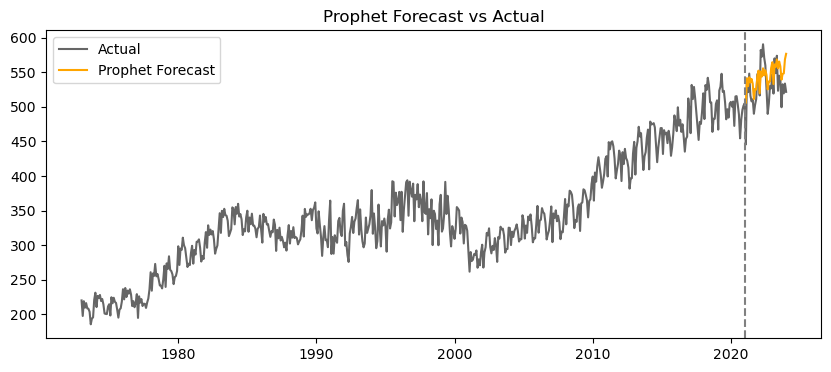

In [7]:


# -------------------------
# 4. MODEL A — Prophet
# -------------------------
metrics = {}
try:

    print("\n=== Prophet ===")
    prophet_df = series.reset_index().rename(columns={'Date':'ds', TARGET_COL:'y'})
    prophet_train = prophet_df[prophet_df['ds']<=train_end]
    prophet_test = prophet_df[prophet_df['ds']>train_end]

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    # Prophet has built-in yearly seasonality; monthly handled by yearly seasonality at monthly granularity
    m.fit(prophet_train)
    future = m.make_future_dataframe(periods=len(prophet_test), freq='MS')
    forecast = m.predict(future)
    prophet_pred = forecast.set_index('ds')['yhat'].loc[prophet_test['ds']].values
    metrics_prophet = eval_metrics(prophet_test['y'].values, prophet_pred)
    metrics['Prophet'] = metrics_prophet
    print("Prophet metrics:", metrics_prophet)
    # plot
    plt.figure(figsize=(10,4))
    plt.plot(series.index, series.values, label='Actual', color='black', alpha=0.6)
    plt.plot(prophet_test['ds'], prophet_pred, label='Prophet Forecast', color='orange')
    plt.axvline(train_end, color='gray', linestyle='--')
    plt.legend(); plt.title("Prophet Forecast vs Actual"); plt.show()
except Exception as e:
    print("Prophet failed:", e)

## 6. Model B — SARIMAX (Seasonal ARIMA with Exogenous Structure)

This section implements the SARIMAX model as a classical statistical time series approach.

SARIMAX extends ARIMA by incorporating seasonal components and is particularly suitable for monthly energy data exhibiting annual seasonality.

---

### Model Specification

The model is defined with:

- Non-seasonal order: (1,1,1)  
  - AR(1): captures short-term autocorrelation  
  - Differencing (d=1): ensures stationarity  
  - MA(1): captures short-term shock effects  

- Seasonal order: (1,1,1,12)  
  - Seasonal AR(1), differencing, and MA(1)  
  - Seasonal period = 12 (monthly yearly seasonality)

Stationarity and invertibility constraints are relaxed to improve model convergence.

---

### Model Estimation

The SARIMAX model is fitted using the training dataset only.  
Maximum iterations are increased to ensure stable convergence.

---

### Residual Diagnostics

To validate model adequacy, residual diagnostics are performed:

1. Ljung–Box Test  
   Tests whether residuals exhibit autocorrelation.  
   A non-significant result suggests residual independence.

2. Residual Time Plot  
   Checks for structural patterns or heteroskedasticity.

3. Residual Distribution (Histogram + KDE)  
   Assesses normality assumption.

Well-behaved residuals indicate that the model has captured the underlying structure effectively.

---

### Forecasting

The model generates multi-step forecasts equal to the test horizon.

Predictions are compared against actual observed values using evaluation metrics (e.g., MAE, RMSE, R²).

Results are stored for later comparison with other models.

---

### Visualization

A plot displays:

- Actual time series
- SARIMAX forecast
- Train–test split boundary

This enables visual inspection of forecast accuracy and seasonal behavior.

---

### Model Persistence

The fitted SARIMAX model is saved to disk for:

- Reproducibility
- Future deployment
- Additional diagnostic analysis

---

SARIMAX serves as the benchmark classical statistical model in this comparative forecasting framework.


=== SARIMAX ===

=== SARIMAX Residual Diagnostics ===
      lb_stat     lb_pvalue
12  56.902157  8.232264e-08


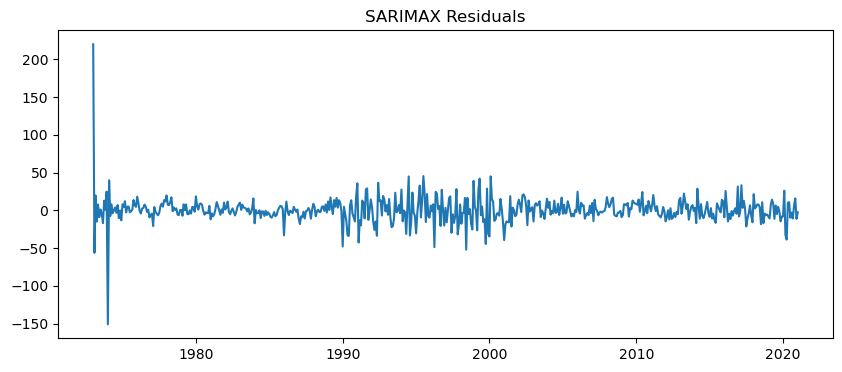

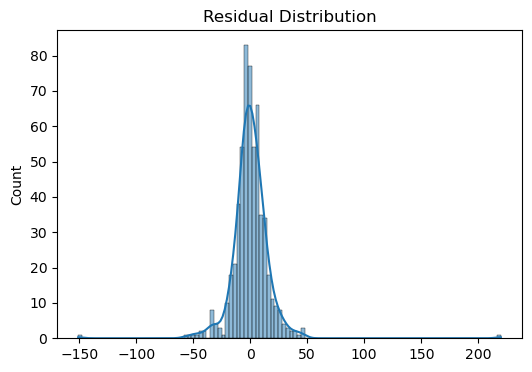

SARIMAX metrics: {'RMSE': 32.60258586608545, 'MAE': 28.23284857530793, 'MAPE (%)': np.float64(5.220530821374088), 'SMAPE (%)': np.float64(5.387346443687764), 'R2': -0.23004542233503034}


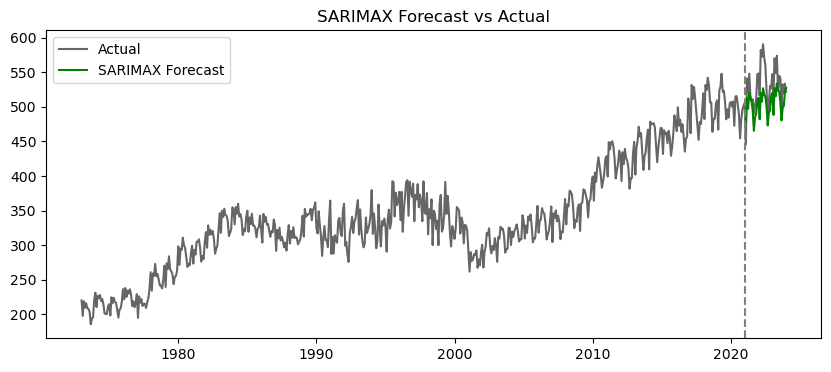

Saved SARIMAX results to models\sarimax_results.pkl


In [8]:
# # -------------------------
# # 5. MODEL B — SARIMAX
# # -------------------------
try:


    print("\n=== SARIMAX ===")

    order = (1,1,1)
    seasonal_order = (1,1,1,12)

    sarimax_model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarimax_res = sarimax_model.fit(disp=False, maxiter=200)

    # ==========================================
    # SARIMAX RESIDUAL DIAGNOSTICS
    # ==========================================

    residuals = sarimax_res.resid.dropna()

    print("\n=== SARIMAX Residual Diagnostics ===")

    # Ljung-Box test
    lb_test = acorr_ljungbox(residuals, lags=[12], return_df=True)
    print(lb_test)

    # Residual plot
    plt.figure(figsize=(10,4))
    plt.plot(residuals)
    plt.title("SARIMAX Residuals")
    plt.show()

    # Histogram
    plt.figure(figsize=(6,4))
    sns.histplot(residuals, kde=True)
    plt.title("Residual Distribution")
    plt.show()

    # ==========================================
    # FORECASTING
    # ==========================================

    sarimax_pred = sarimax_res.get_forecast(steps=len(test)).predicted_mean

    metrics_sarimax = eval_metrics(test.values, sarimax_pred.values)
    metrics['SARIMAX'] = metrics_sarimax
    print("SARIMAX metrics:", metrics_sarimax)

    plt.figure(figsize=(10,4))
    plt.plot(series.index, series.values, label='Actual', color='black', alpha=0.6)
    plt.plot(test.index, sarimax_pred, label='SARIMAX Forecast', color='green')
    plt.axvline(train_end, color='gray', linestyle='--')
    plt.legend()
    plt.title("SARIMAX Forecast vs Actual")
    plt.show()

    # Save model
    sarimax_path = os.path.join(MODELS_DIR, "sarimax_results.pkl")
    try:
        sarimax_res.save(sarimax_path)
        print("Saved SARIMAX results to", sarimax_path)
    except Exception as e:
        print("Could not save SARIMAX results file:", e)

except Exception as e:
    print("SARIMAX failed:", e)

## 7. Model C — XGBoost Regression

This section implements XGBoost as a machine learning–based forecasting model.

XGBoost is a gradient boosting algorithm that builds an ensemble of decision trees sequentially, where each new tree corrects errors from previous trees. It is well-suited for capturing nonlinear patterns and complex feature interactions.

---

### Model Configuration

The model is initialized with:

- 500 trees (`n_estimators=500`)
- Learning rate = 0.05 (controls update step size)
- Maximum tree depth = 4 (limits model complexity)
- Squared error objective (regression task)
- Fixed random state for reproducibility

These hyperparameters balance model flexibility and overfitting risk.

---

### Training and Prediction

The model is trained on the engineered feature matrix (`X_train`, `y_train`), which includes:

- Lag features
- Rolling statistics
- Monthly dummy variables
- Time index

Forecasts are generated for the test set and evaluated using predefined performance metrics (e.g., MAE, RMSE, R²).

---

### Visualization

A comparison plot shows:

- Actual observed values
- XGBoost forecast
- Train–test split boundary

This allows visual inspection of forecast accuracy and trend tracking ability.

---

### Model Saving

The trained XGBoost model is saved using `joblib` for:

- Reproducibility
- Deployment
- Future inference without retraining

---

XGBoost represents the nonlinear machine learning benchmark in this comparative forecasting framework.


=== XGBoost ===
XGBoost metrics: {'RMSE': 42.68052870421725, 'MAE': 37.76101616075303, 'MAPE (%)': np.float64(6.997244695375889), 'SMAPE (%)': np.float64(7.277170323277433), 'R2': -1.1080292638546543}


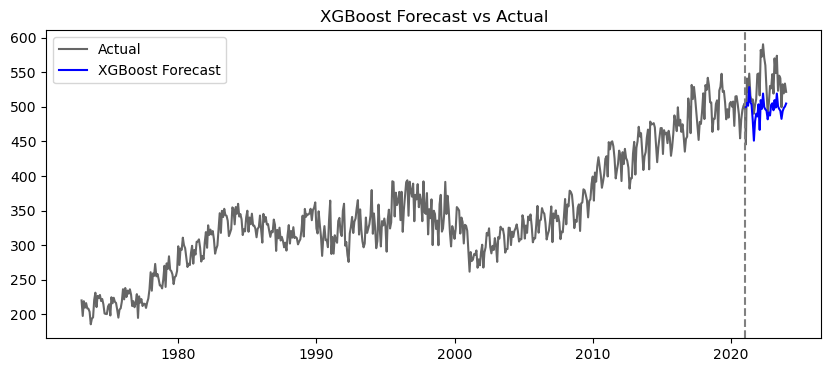

Saved XGBoost model to models\xgb_model.joblib


In [9]:
# -------------------------
# 6. MODEL C — XGBoost
# -------------------------
try:
    
    print("\n=== XGBoost ===")
    xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                       objective='reg:squarederror', random_state=42, verbosity=0)
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    metrics_xgb = eval_metrics(y_test.values, xgb_pred)
    metrics['XGBoost'] = metrics_xgb
    print("XGBoost metrics:", metrics_xgb)
    plt.figure(figsize=(10,4))
    plt.plot(series.index, series.values, label='Actual', color='black', alpha=0.6)
    plt.plot(test.index, xgb_pred, label='XGBoost Forecast', color='blue')
    plt.axvline(train_end, color='gray', linestyle='--')
    plt.legend(); plt.title("XGBoost Forecast vs Actual"); plt.show()
    # save xgb model
    
    xgb_path = os.path.join(MODELS_DIR, "xgb_model.joblib")
    joblib.dump(xgb, xgb_path)
    print("Saved XGBoost model to", xgb_path)
except Exception as e:
    print("XGBoost failed:", e)


## 8. Model D — LSTM (Long Short-Term Memory Network)

This section implements an LSTM neural network as a deep learning approach to time series forecasting.

LSTM is a type of recurrent neural network (RNN) designed to capture long-term dependencies and nonlinear temporal patterns. It is particularly useful when relationships in the data are complex and not well modeled by linear assumptions.

---

### Data Scaling

Neural networks require normalized input data. Therefore:

- Feature matrix (`X`) and target (`y`) are scaled using MinMaxScaler.
- Scaling prevents dominance of large numerical values and improves training stability.

After prediction, outputs are inverse-transformed back to the original scale for evaluation.

---

### Input Reshaping

LSTM models expect 3D input of shape:

    [samples, timesteps, features]

In this implementation:
- `timesteps = 1`
- Lag and rolling features serve as the feature dimension

This structure allows the LSTM to learn nonlinear interactions among time-based predictors.

---

### Network Architecture

The model consists of:

- One LSTM layer (64 units)
- Dropout layer (20%) to reduce overfitting
- Dense output layer (1 neuron for regression)

The model is compiled with:
- Adam optimizer
- Mean Squared Error (MSE) loss function

---

### Training Strategy

- Maximum 200 epochs
- Batch size = 16
- 15% validation split
- Early stopping with patience of 10 epochs

Early stopping prevents overfitting by restoring the best-performing weights.

---

### Forecasting and Evaluation

Predictions are generated for the test set and transformed back to the original scale.

Performance metrics (e.g., MAE, RMSE, R²) are computed and stored for later model comparison.

---

### Model Saving

The trained LSTM model is saved in `.h5` format for:

- Reproducibility
- Deployment
- Further experimentation

---

The LSTM model represents the deep learning benchmark in this multi-model forecasting comparison.


=== LSTM ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
LSTM metrics: {'RMSE': 18.68514763785503, 'MAE': 15.370490498860672, 'MAPE (%)': np.float64(2.9124970205392247), 'SMAPE (%)': np.float64(2.9101829475720757), 'R2': 0.5959732484403337}


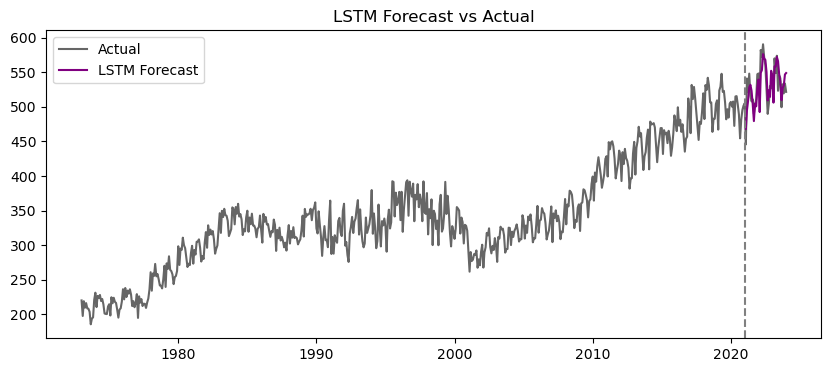

Saved LSTM model to models\lstm_model.h5


In [10]:
# -------------------------
# 7. MODEL D — LSTM (Optional)
# -------------------------
lstm_ran = False
try:


    print("\n=== LSTM ===")
    # Prepare scaled features
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s = scaler_X.transform(X_test)
    y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1,1)).flatten()
    y_test_s = scaler_y.transform(y_test.values.reshape(-1,1)).flatten()

    # reshape for LSTM [samples, timesteps, features] — we use timesteps=1 with lag features as features
    X_train_l = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
    X_test_l = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

    model = Sequential()
    model.add(LSTM(64, input_shape=(X_train_l.shape[1], X_train_l.shape[2]), return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train_l, y_train_s, epochs=200, batch_size=16,
                        validation_split=0.15, callbacks=[es], verbose=0)

    lstm_pred_s = model.predict(X_test_l).flatten()
    lstm_pred = scaler_y.inverse_transform(lstm_pred_s.reshape(-1,1)).flatten()
    metrics_lstm = eval_metrics(y_test.values, lstm_pred)
    metrics['LSTM'] = metrics_lstm
    lstm_ran = True
    print("LSTM metrics:", metrics_lstm)

    plt.figure(figsize=(10,4))
    plt.plot(series.index, series.values, label='Actual', color='black', alpha=0.6)
    plt.plot(test.index, lstm_pred, label='LSTM Forecast', color='purple')
    plt.axvline(train_end, color='gray', linestyle='--')
    plt.legend(); plt.title("LSTM Forecast vs Actual"); plt.show()

    # save model
    lstm_path = os.path.join(MODELS_DIR, "lstm_model.h5")
    model.save(lstm_path)
    print("Saved LSTM model to", lstm_path)

except Exception as e:
    print("LSTM skipped or failed (TensorFlow may not be installed):", e)


## 9. Final Model Comparison and Performance Evaluation

This section consolidates the forecasting performance of all implemented models into a unified comparison table.

The evaluation metrics are collected from each model and stored in a structured dataframe for transparent comparison.

---

### Evaluation Metrics

The following performance indicators are used:

- RMSE (Root Mean Squared Error)  
- MAE (Mean Absolute Error)  
- MAPE (%) (Mean Absolute Percentage Error)  
- SMAPE (%) (Symmetric Mean Absolute Percentage Error)  
- R² (Coefficient of Determination)

For RMSE, MAE, MAPE, and SMAPE:
- Lower values indicate better forecasting accuracy.

For R²:
- Higher values indicate better explanatory power.

---

### Comparative Analysis

The results table allows:

- Direct ranking of models
- Identification of the most accurate forecasting approach
- Evaluation of trade-offs between statistical, machine learning, and deep learning models

This structured comparison forms the basis for selecting the final model used for interpretation and potential deployment.

---

### Reproducibility

The complete results table is exported as a CSV file to:

- Ensure reproducibility
- Facilitate reporting in the thesis document
- Enable further statistical comparison or visualization

---

This final comparison step integrates all modeling approaches into a unified evaluation framework and concludes the forecasting pipeline.

In [11]:
# -------------------------
# 8. Final comparison table
# -------------------------
results_df = pd.DataFrame.from_dict(metrics, orient='index')
# order columns for readability
cols_order = ["RMSE","MAE","MAPE (%)","SMAPE (%)","R2"]
results_df = results_df[cols_order]
print("\nModel comparison (lower is better for RMSE/MAE/MAPE/SMAPE):")
display(results_df)

# Save results
results_csv = os.path.join(MODELS_DIR, "model_metrics_summary.csv")
results_df.to_csv(results_csv)
print("Saved model metrics summary to", results_csv)

print("\nPipeline finished. Project PDF reference path:", PROJECT_PDF_PATH)



Model comparison (lower is better for RMSE/MAE/MAPE/SMAPE):


,RMSE,MAE,MAPE (%),SMAPE (%),R2
Prophet,25.652939,21.366814,4.100316,4.010726,0.238462
SARIMAX,32.602586,28.232849,5.220531,5.387346,-0.230045
XGBoost,42.680529,37.761016,6.997245,7.277170,-1.108029
LSTM,18.685148,15.370490,2.912497,2.910183,0.595973


Saved model metrics summary to models\model_metrics_summary.csv

Pipeline finished. Project PDF reference path: /mnt/data/big_data_analysis_project.pdf


## 10. Finalized Modeling Pipeline Configuration

This section defines the finalized forecasting pipeline, integrating macro-level inputs and standardized visualization outputs.

The pipeline includes the following forecasting models:

- Prophet (additive decomposition model)
- SARIMAX (classical seasonal time series model)
- XGBoost (machine learning regression model)
- Optional LSTM (deep learning approach)

---

### Reproducibility Settings

To ensure full reproducibility of results:

- A fixed random seed (`SEED = 42`) is applied
- NumPy, Python random module, and hash seed are controlled

This guarantees consistent model initialization, training behavior, and evaluation outcomes across runs.

---

### Project and Data Paths

Key directories and file paths are defined:

- Cleaned U.S. renewable energy dataset
- Global energy dataset (macro-level inputs)
- Model storage directory
- Output directory for generated results
- Reference path to the project PDF

Directories are created automatically if they do not exist, ensuring portability and structured output management.

---

### Evaluation Metrics

Custom evaluation functions are implemented for:

- RMSE
- MAE
- MAPE
- SMAPE
- R²

These metrics provide a balanced assessment of:

- Absolute forecast error
- Relative percentage error
- Model explanatory strength

A unified `eval_metrics()` function standardizes performance comparison across all models.

---

### Visualization Utilities

Two reusable plotting functions are defined:

1. `plot_forecast()`  
   - Displays full historical data
   - Highlights training and test sets
   - Shows model predictions for the evaluation horizon
   - Optionally saves high-resolution figures

2. `plot_future()`  
   - Visualizes extended future forecasts beyond observed data
   - Clearly separates historical and projected values

These functions ensure:

- Clean and consistent forecasting visuals
- Clear separation of training, testing, and future projections
- Publication-quality figures suitable for thesis inclusion

---

This finalized configuration establishes a structured, reproducible, and extensible forecasting framework that integrates statistical, machine learning, and deep learning approaches within a unified evaluation pipeline.

In [12]:
# FINALIZED modelling pipeline with macro inputs + clean forecasting visuals
# Models: Prophet, SARIMAX, XGBoost, optional LSTM
# Requires: pandas, numpy, matplotlib, seaborn, scikit-learn, xgboost, statsmodels, prophet, joblib
# Optional: tensorflow (for LSTM)
# PROJECT_PDF_PATH local reference: /mnt/data/big_data_analysis_project.pdf



# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

PROJECT_PDF_PATH = "/mnt/data/big_data_analysis_project.pdf"

# Paths & settings
DATA_PATH = "datasets/clean_us_agg.csv"
GLOBAL_PATH = "datasets/global_energy_consumption.csv"
TARGET_COL = "Total Renewable Energy"
MODELS_DIR = "models"
OUT_DIR = "datasets/outputs"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Utility metrics
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask]-y_pred[mask]) / y_true[mask])) * 100 if mask.any() else np.nan

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    return 100*np.mean(2.0 * np.abs(y_pred[mask]-y_true[mask]) / denom[mask]) if mask.any() else np.nan

def eval_metrics(y_true, y_pred):
    return {
        "RMSE": sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE (%)": mape(y_true, y_pred),
        "SMAPE (%)": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Plot helper: clear, explicit forecast plots
def plot_forecast(series, train, test, pred, title, savepath=None):
    plt.figure(figsize=(14,6))
    plt.plot(series.index, series.values, label="Historical (All)", color="black", linewidth=1.2)
    plt.plot(train.index, train.values, label="Training Data", color="tab:blue", linewidth=1.6)
    plt.plot(test.index, test.values, label="Actual (Test)", color="tab:green", linewidth=2)
    plt.plot(test.index, pred, label="Model Forecast (Test Horizon)", color="tab:red", linestyle="--", linewidth=2)
    plt.axvline(train.index[-1], color="gray", linestyle="--")
    plt.title(title, fontsize=14)
    plt.xlabel("Date"); plt.ylabel(TARGET_COL)
    plt.legend(); plt.grid(True)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150)
    plt.show()

def plot_future(series, future_index, future_pred, title, savepath=None):
    plt.figure(figsize=(14,6))
    plt.plot(series.index, series.values, label="Historical", color="black")
    plt.plot(future_index, future_pred, label="Forecast (Future)", color="purple", linestyle="--", linewidth=2)
    plt.axvline(series.index[-1], color="gray", linestyle="--")
    plt.title(title, fontsize=14)
    plt.xlabel("Date"); plt.ylabel(TARGET_COL)
    plt.legend(); plt.grid(True)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150)
    plt.show()


## 11. Loading and Preparing the Cleaned U.S. Monthly Renewable Energy Series

This section loads the finalized and preprocessed U.S. renewable energy dataset, which serves as the primary target series for forecasting.

---

### Data Import

The dataset is loaded from the predefined `DATA_PATH`:

- The first column is treated as the time index.
- Date parsing is enabled to ensure proper time series handling.
- The index is renamed to "Date" for clarity.
- The dataset is sorted chronologically to maintain temporal consistency.

A validation check ensures that the selected target variable (`TARGET_COL`) exists in the dataset.  
If the column is missing, execution is stopped to prevent downstream modeling errors.

---

### Time Series Formatting

The target series is extracted and converted to a fixed:

- Monthly start frequency (`MS`)

Ensuring consistent monthly spacing is essential for:

- SARIMAX seasonal modeling
- Prophet yearly seasonality
- Feature engineering for machine learning models

---

### Missing Value Handling

To guarantee a continuous time series:

- Linear interpolation is applied
- Forward-fill and backward-fill are used as fallback methods

This step ensures that no gaps remain in the data, which is critical for stable model training and forecasting accuracy.

---

At this stage, the renewable energy time series is fully structured, continuous, and ready for modeling.

In [13]:
# 1. Load cleaned US monthly series
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df.index.name = "Date"
df = df.sort_index()
print("Loaded:", DATA_PATH, "shape:", df.shape)
if TARGET_COL not in df.columns:
    raise ValueError(f"Target '{TARGET_COL}' not in {DATA_PATH} columns: {df.columns.tolist()}")
series = df[TARGET_COL].asfreq('MS')
series = series.interpolate().fillna(method='ffill').fillna(method='bfill')


Loaded: datasets/clean_us_agg.csv shape: (613, 14)


## 12. Integration of Global Macroeconomic Variables

This section incorporates global macro-level energy indicators into the forecasting framework to enrich the information set beyond the univariate renewable energy series.

---

### Loading Global Dataset

The global energy dataset is loaded from the predefined `GLOBAL_PATH`.  
A validation step ensures that the file exists before proceeding.

Since global datasets often contain multiple country-level observations per year, additional preprocessing is required to obtain consistent macro-level indicators.

---

### Selection of Relevant Variables

Only numeric variables are selected as potential macro predictors.  

- The column `Year` is excluded from predictor selection.
- If no numeric variables are available, execution stops to prevent model errors.

This ensures that only meaningful quantitative macro inputs are used.

---

### Annual Aggregation

To eliminate duplicate yearly entries (e.g., multiple country records per year):

- The dataset is grouped by `Year`
- The mean value across countries is calculated for each numeric variable

This produces one aggregated macro observation per year.

---

### Conversion to Monthly Frequency

Because the renewable energy target series is monthly:

- Yearly macro data is converted to a datetime format (January 1 of each year)
- The data is resampled to monthly start frequency (`MS`)
- Linear interpolation is applied to create smooth monthly estimates
- Forward-fill and backward-fill ensure no missing values remain

This step aligns macro variables with the monthly renewable energy series.

---

### Time Alignment

The macro dataset is restricted to match the time range of the renewable energy series.  
This guarantees:

- Temporal consistency
- No data leakage
- Proper model alignment

The aligned macro dataset is saved for reproducibility and transparency.

---

### Purpose of Macro Integration

Including macro-level variables allows the forecasting models to:

- Capture global energy trends
- Account for structural shifts
- Improve predictive robustness
- Move beyond purely autoregressive dynamics

This transforms the forecasting task from a purely univariate problem into a macro-informed predictive framework.

In [14]:
# 2. Load global macro, aggregate by Year -> monthly
if not os.path.exists(GLOBAL_PATH):
    raise FileNotFoundError(f"{GLOBAL_PATH} not found")
df_global = pd.read_csv(GLOBAL_PATH)
print("Loaded global macro:", GLOBAL_PATH, "shape:", df_global.shape)

# pick numeric cols (exclude Year)
numeric_global_cols = df_global.select_dtypes(include=[np.number]).columns.tolist()
if "Year" in numeric_global_cols: numeric_global_cols.remove("Year")
if not numeric_global_cols:
    raise ValueError("No numeric columns in global dataset to use as macro inputs.")

# group by Year to avoid duplicate years (e.g., country rows)
df_global_grouped = df_global.groupby("Year")[numeric_global_cols].mean().reset_index()
df_global_grouped["Date"] = pd.to_datetime(df_global_grouped["Year"].astype(int).astype(str) + "-01-01")
macro = df_global_grouped.set_index("Date")[numeric_global_cols].sort_index()
macro_monthly = macro.resample("MS").interpolate(method="linear").ffill().bfill()
macro_monthly = macro_monthly.loc[series.index.min():series.index.max()]
macro_monthly.to_csv(os.path.join(OUT_DIR, "macro_monthly_aligned.csv"))
macro_cols = macro_monthly.columns.tolist()
print("Macro cols used:", macro_cols, "shape:", macro_monthly.shape)


Loaded global macro: datasets/global_energy_consumption.csv shape: (10000, 10)
Macro cols used: ['Total Energy Consumption (TWh)', 'Per Capita Energy Use (kWh)', 'Renewable Energy Share (%)', 'Fossil Fuel Dependency (%)', 'Industrial Energy Use (%)', 'Household Energy Use (%)', 'Carbon Emissions (Million Tons)', 'Energy Price Index (USD/kWh)'] shape: (289, 8)


## 13. Chronological Train–Test Split

To ensure a realistic and unbiased evaluation of forecasting performance, the time series is divided into training and test sets using a chronological split.

---

### Forecast Horizon

A fixed test horizon of 36 months (3 years) is reserved as the out-of-sample evaluation period.

This medium-term horizon is appropriate for:

- Energy policy analysis
- Capacity planning
- Medium-term strategic forecasting

---

### Training Set

The training dataset includes all observations from the beginning of the series up to:

    Last Available Date − 36 Months

This subset is used to:

- Fit statistical models (SARIMAX)
- Train machine learning models (XGBoost)
- Train deep learning models (LSTM)
- Fit additive models (Prophet)

---

### Test Set

The test dataset consists of the final 36 months of observations.

It is strictly excluded from model training and used exclusively to evaluate:

- Forecast accuracy
- Model generalization performance
- Robustness across different modeling approaches

---

### Why Chronological Splitting?

Unlike conventional machine learning workflows, time series data must preserve temporal ordering.

Random shuffling would introduce data leakage by allowing future information to influence model training.

A chronological split ensures:

- Realistic forecasting conditions
- No leakage of future data
- Valid out-of-sample evaluation

---

This structured split establishes a fair comparison framework for all forecasting models in the pipeline.

In [15]:
# 3. Train/test split
test_horizon = 36
train_end = series.index[-1] - pd.DateOffset(months=test_horizon)
train = series[:train_end]; test = series[train_end + pd.DateOffset(months=1):]
print("Train:", train.index.min(), "->", train.index.max(), "(", len(train), "months )")
print("Test :", test.index.min(), "->", test.index.max(), "(", len(test), "months )")


Train: 1973-01-01 00:00:00 -> 2021-01-01 00:00:00 ( 577 months )
Test : 2021-02-01 00:00:00 -> 2024-01-01 00:00:00 ( 36 months )


## 14. Feature Engineering and Integration of Macroeconomic Variables

This section transforms the univariate renewable energy time series into a supervised learning dataset and enriches it with macro-level predictors.

This step is required for machine learning and deep learning models such as XGBoost and LSTM, which cannot directly operate on raw time series data.

---

### 14.1 Lag Features

Lag variables are created to capture autoregressive dependencies:

- Lag 1 → Previous month
- Lag 12 → Same month in the previous year (seasonality)
- Lag 24 → Two years prior

These features allow the model to learn short-term persistence and annual seasonal effects.

---

### 14.2 Rolling Statistics

Rolling mean features are computed over:

- 3 months → Short-term smoothing
- 12 months → Annual trend representation
- 36 months → Long-term structural trend

Rolling features help capture trend strength and reduce sensitivity to noise.  
They are shifted by one period to prevent data leakage.

---

### 14.3 Time-Based Features

Additional temporal features include:

- `time_idx` → Linear time progression index
- Monthly dummy variables → Explicit seasonal encoding

Month dummies allow flexible modeling of intra-year seasonal variation without imposing sinusoidal assumptions.

---

### 14.4 Alignment and Data Cleaning

Lag construction introduces missing values at the beginning of the series.  
These rows are removed to ensure a clean feature matrix.

The resulting feature dataframe is realigned with the correct timestamps.

---

### 14.5 Integration of Macroeconomic Variables

The engineered feature matrix is merged with the aligned monthly macro dataset.

Missing macro values are handled using:

- Forward-fill
- Backward-fill
- Zero fallback (if necessary)

This ensures complete alignment and avoids training instability.

---

### 14.6 Final Supervised Learning Dataset

The dataset is split into:

- `X_train`, `y_train`
- `X_test`, `y_test`

This transforms the original time series into a structured predictive dataset suitable for:

- XGBoost regression
- LSTM neural networks

By integrating both internal (lag-based) and external (macro-level) information, the forecasting framework moves from a purely autoregressive setup to a macro-informed predictive modeling strategy.

In [16]:
# 4. Feature engineering and merge macro (for XGBoost/LSTM)
def make_features(s, lags=[1,12,24], rolling_windows=[3,12,36]):
    dfF = pd.DataFrame({"y": s})
    dfF['time_idx'] = np.arange(len(dfF))
    dfF['month'] = dfF.index.month
    month_dummies = pd.get_dummies(dfF['month'].astype(int).astype(str), prefix='m', drop_first=False)
    dfF = pd.concat([dfF, month_dummies], axis=1)
    for lag in lags:
        dfF[f"lag_{lag}"] = dfF['y'].shift(lag)
    for w in rolling_windows:
        dfF[f"rmean_{w}"] = dfF['y'].rolling(window=w, min_periods=1).mean().shift(1)
    dfF = dfF.drop(columns=['month']).dropna()
    return dfF

df_feats = make_features(series)
df_feats.index = series.index[-len(df_feats):]
df_feats = df_feats.merge(macro_monthly, left_index=True, right_index=True, how='left')
df_feats[macro_cols] = df_feats[macro_cols].fillna(method='ffill').fillna(method='bfill').fillna(0)
df_train = df_feats[df_feats.index <= train_end].copy()
df_test = df_feats[df_feats.index > train_end].copy()
X_train = df_train.drop(columns=['y']); y_train = df_train['y']
X_test = df_test.drop(columns=['y']); y_test = df_test['y']
print("Feature shapes:", X_train.shape, X_test.shape)

metrics = {}


Feature shapes: (553, 27) (36, 27)


## 15. Prophet with Macroeconomic Regressors

This section extends the baseline Prophet model by incorporating external macroeconomic variables as additional regressors.

By integrating macro-level energy indicators, the model moves from a purely univariate framework to a macro-informed forecasting approach.

---

### Model Structure

Prophet decomposes the time series into:

- Trend component
- Yearly seasonality
- Error term

In this enhanced version, macroeconomic variables are added using `add_regressor()`.  
This allows the model to capture relationships between renewable energy generation and global energy trends.

---

### Training Procedure

1. The target series is reformatted into Prophet’s required structure:
   - `ds` → Date
   - `y` → Target variable

2. Macro variables are merged with the training and test datasets.

3. The model is configured with:
   - Yearly seasonality enabled
   - Weekly and daily seasonalities disabled (monthly data)

4. Each macro variable is explicitly added as an external regressor.

The model is then fitted on the training dataset only.

---

### Test Forecasting

Predictions are generated for the full test horizon:

- Forecasted values (`yhat`) corresponding to test dates are extracted.
- Performance metrics (RMSE, MAE, MAPE, SMAPE, R²) are computed.
- Results are stored for final model comparison.

A clean visualization compares:

- Historical values
- Test-period actual values
- Prophet forecast
- Train–test boundary

---

### Future Forecasting (36-Month Projection)

Beyond test evaluation, the model generates a 36-month forward projection.

Since future macro values are unknown, a practical assumption is applied:

- The last observed macro values are extended forward.
- This represents a baseline scenario (status quo macro conditions).

The future forecast is visualized separately to clearly distinguish:

- Historical observations
- Future projected values

---

### Purpose of Macro Integration in Prophet

Adding macro regressors allows the model to:

- Capture structural shifts in global energy markets
- Improve robustness against trend breaks
- Reflect external economic influences
- Enhance interpretability of drivers behind renewable energy growth

This configuration transforms Prophet from a purely trend-seasonality model into a semi-structural forecasting framework.

In [17]:
# 5. Prophet (with macro regressors)
try:
    
    print("\nRunning Prophet...")
    prophet_df = series.reset_index().rename(columns={'Date':'ds', TARGET_COL:'y'})
    prophet_train = prophet_df[prophet_df['ds'] <= train_end].copy()
    prophet_test = prophet_df[prophet_df['ds'] > train_end].copy()
    prophet_train = prophet_train.merge(macro_monthly, left_on='ds', right_index=True, how='left')
    prophet_test = prophet_test.merge(macro_monthly, left_on='ds', right_index=True, how='left')
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    for col in macro_cols: m.add_regressor(col)
    m.fit(prophet_train)
    future = m.make_future_dataframe(periods=len(prophet_test), freq='MS')
    future = future.merge(macro_monthly, left_on='ds', right_index=True, how='left')
    forecast = m.predict(future)
    prophet_pred = forecast.set_index('ds')['yhat'].loc[prophet_test['ds']].values
    metrics_prophet = eval_metrics(prophet_test['y'].values, prophet_pred)
    metrics['Prophet'] = metrics_prophet
    print("Prophet metrics:", metrics_prophet)
    plot_forecast(series, train, test, prophet_pred, "Prophet Forecast (test horizon)", savepath=os.path.join(OUT_DIR,"prophet_test.png"))
    # FUTURE forecast (36 months)
    future_full = m.make_future_dataframe(periods=36, freq='MS')
    # need macro for future: use last available trend, extend last known values forward (or better a scenario)
    macro_future = macro_monthly.copy()
    last_macro_row = macro_future.iloc[-1]
    future_index = pd.date_range(start=series.index[-1] + pd.DateOffset(months=1), periods=36, freq='MS')
    future_macro_df = pd.DataFrame([last_macro_row.values]*36, index=future_index, columns=macro_future.columns)
    future_full = future_full.merge(pd.concat([macro_future, future_macro_df]), left_on='ds', right_index=True, how='left')
    forecast_full = m.predict(future_full)
    prop_future_pred = forecast_full.set_index('ds')['yhat'].loc[future_index].values
    plot_future(series, future_index, prop_future_pred, "Prophet Future Forecast (36 months)", savepath=os.path.join(OUT_DIR,"prophet_future.png"))
except Exception as e:
    print("Prophet skipped/failed:", e)




Running Prophet...


DEBUG:cmdstanpy:cmd: where.exe tbb.dll
cwd: None
DEBUG:cmdstanpy:TBB already found in load path


Prophet skipped/failed: Found NaN in column 'Total Energy Consumption (TWh)'


## 16. XGBoost with Macroeconomic Features and Recursive Future Forecasting

This section implements XGBoost as a nonlinear machine learning forecasting model enhanced with macroeconomic predictors.  
In addition to test-set evaluation, a recursive multi-step future forecasting strategy is applied.

---

### Model Configuration

XGBoost is initialized with:

- 500 boosting trees  
- Learning rate = 0.05  
- Maximum tree depth = 4  
- Squared error objective function  
- Fixed random seed for reproducibility  

This configuration balances model flexibility and overfitting control.

The model is trained on the engineered feature matrix, which includes:

- Lag features  
- Rolling mean features  
- Monthly dummy variables  
- Time index  
- Macroeconomic variables  

---

### Test Horizon Forecasting

Predictions are generated for the 36-month test horizon.

Forecast accuracy is evaluated using:

- RMSE  
- MAE  
- MAPE  
- SMAPE  
- R²  

Results are stored for final model comparison, and forecasts are visualized against actual values.

The trained model is saved using `joblib` to ensure reproducibility and potential deployment.

---

### Recursive Multi-Step Future Forecasting

Unlike statistical models, XGBoost does not inherently generate multi-step forecasts.  
Therefore, a recursive forecasting strategy is implemented:

1. Predict the next month using the latest available features.
2. Append the predicted value to the temporary series.
3. Recalculate lag and rolling features.
4. Repeat the process for 36 steps.

This approach simulates real-world forecasting where future values are unknown and must be generated sequentially.

---

### Handling Macroeconomic Variables in Future Forecasting

For future periods:

- If macro data exists, it is used directly.
- If unavailable, the last observed macro values are carried forward.

This assumption represents a baseline macroeconomic scenario.

---

### Output

Two types of forecasts are produced:

1. Test-horizon forecast (model evaluation)
2. 36-month future projection (forward-looking analysis)

Clean visualization functions are used to ensure publication-quality figures.

---

### Role in the Forecasting Framework

XGBoost represents the nonlinear machine learning benchmark within the comparative modeling framework.

Its recursive forecasting capability allows:

- Flexible modeling of complex interactions
- Integration of external macro drivers
- Long-horizon scenario-based projections

This makes it a strong candidate for capturing nonlinear growth patterns in renewable energy generation.


Running XGBoost...
XGBoost metrics: {'RMSE': 48.62042090782013, 'MAE': 43.48328839789495, 'MAPE (%)': np.float64(8.039739946711109), 'SMAPE (%)': np.float64(8.42244420128469), 'R2': -1.7356118903897029}


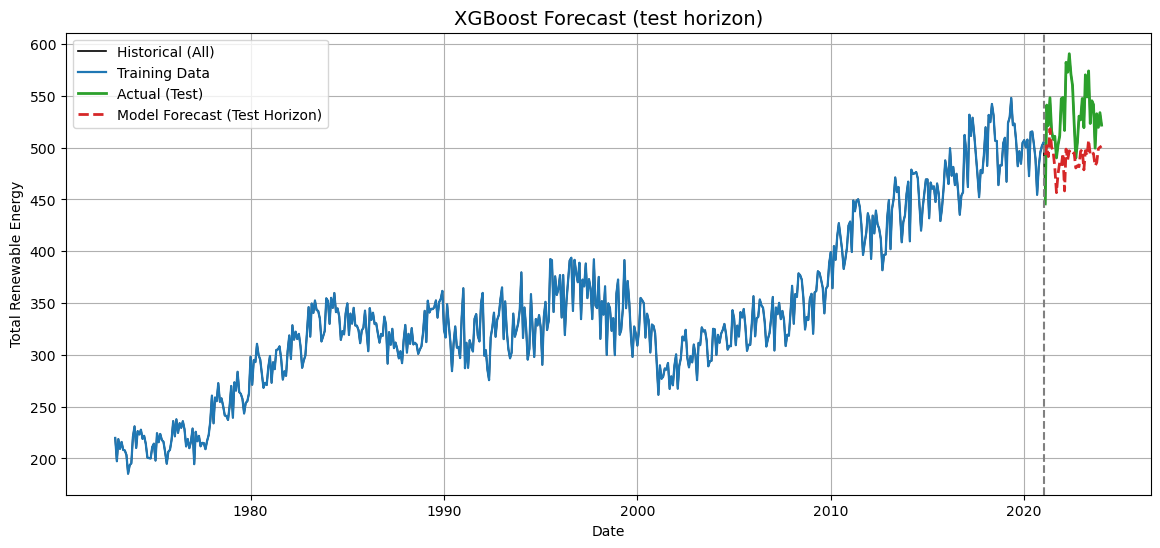

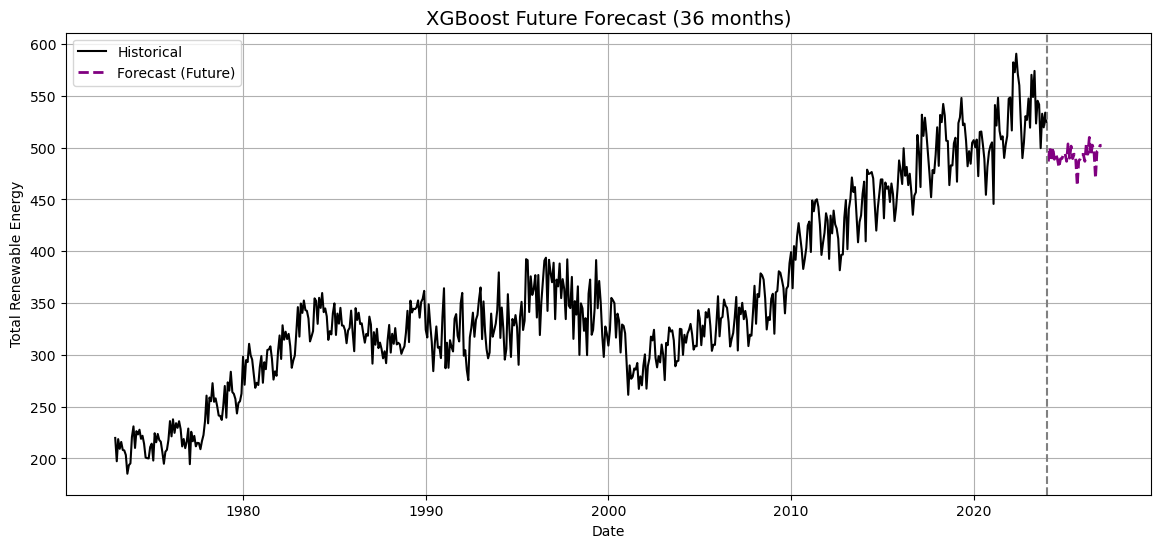

In [18]:
# 7. XGBoost (with macro features) - + recursive future forecasting
try:

    print("\nRunning XGBoost...")
    xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                       objective='reg:squarederror', random_state=SEED, verbosity=0)
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    metrics_xgb = eval_metrics(y_test.values, xgb_pred)
    metrics['XGBoost'] = metrics_xgb
    print("XGBoost metrics:", metrics_xgb)
    plot_forecast(series, train, test, xgb_pred, "XGBoost Forecast (test horizon)", savepath=os.path.join(OUT_DIR,"xgb_test.png"))
    joblib.dump(xgb, os.path.join(MODELS_DIR, "xgb_model.joblib"))
    # Recursive future forecast for XGBoost using last available features
    def recursive_xgb_forecast(series, df_feats, macro_monthly, model, steps=36):
        preds = []
        temp_series = series.copy()
        feats = df_feats.copy()
        for i in range(steps):
            last_idx = feats.index[-1]
            # build next timestamp
            next_ts = last_idx + pd.DateOffset(months=1)
            # create features for next timestamp using last values
            row = {}
            row['y'] = np.nan
            row['time_idx'] = feats['time_idx'].iloc[-1] + 1
            month = next_ts.month
            # month dummies
            for mcol in [c for c in feats.columns if c.startswith('m_')]:
                row[mcol] = 1 if mcol == f"m_{month}" else 0
            # lags from temp_series
            for lag in [1,12,24]:
                val = temp_series.iloc[-lag] if len(temp_series) >= lag else temp_series.iloc[-1]
                row[f'lag_{lag}'] = val
            for w in [3,12,36]:
                row[f"rmean_{w}"] = temp_series.tail(w).mean()
            # macro features: use macro_monthly if available, else carry-forward last
            if next_ts in macro_monthly.index:
                for col in macro_monthly.columns:
                    row[col] = macro_monthly.loc[next_ts, col]
            else:
                for col in macro_monthly.columns:
                    row[col] = macro_monthly.iloc[-1][col]
            # form row df
            row_df = pd.DataFrame(row, index=[next_ts])
            # ensure same columns order as model input
            Xrow = row_df.drop(columns=['y'])
            # align Xrow to model features (some safety)
            Xrow = Xrow.reindex(columns=model.get_booster().feature_names, fill_value=0) if hasattr(model, "get_booster") else Xrow.reindex(columns=X_train.columns, fill_value=0)
            pred = model.predict(Xrow)[0]
            preds.append(pred)
            # append to temp_series and feats for next iteration
            temp_series.loc[next_ts] = pred
            row_df['y'] = pred
            feats = pd.concat([feats, row_df])
        # return preds and index
        future_index = pd.date_range(start=series.index[-1] + pd.DateOffset(months=1), periods=steps, freq='MS')
        return pd.Series(preds, index=future_index)
    try:
        xgb_future = recursive_xgb_forecast(series, df_feats, macro_monthly, xgb, steps=36)
        plot_future(series, xgb_future.index, xgb_future.values, "XGBoost Future Forecast (36 months)", savepath=os.path.join(OUT_DIR,"xgb_future.png"))
    except Exception as e:
        print("XGBoost future recursive forecast failed:", e)
except Exception as e:
    print("XGBoost skipped/failed:", e)





## 17. LSTM with Macroeconomic Features and Recursive Multi-Step Forecasting (Optional)

This section implements a Long Short-Term Memory (LSTM) neural network as the deep learning component of the forecasting framework.  
The model incorporates both engineered time-series features and macroeconomic variables.

The LSTM model is optional and executed only if TensorFlow is available.

---

### Data Scaling

Neural networks require normalized input for stable training.

Therefore:

- Feature matrix (`X`) is scaled using MinMaxScaler.
- Target variable (`y`) is scaled separately.
- After prediction, outputs are inverse-transformed to their original scale.

Scaling ensures:

- Faster convergence
- Reduced numerical instability
- Balanced feature influence

---

### Input Reshaping

LSTM models expect 3-dimensional input:

    [samples, timesteps, features]

In this configuration:

- `timesteps = 1`
- Lag, rolling, seasonal, and macro features serve as the feature dimension.

Although the temporal structure is embedded via lag features, the LSTM can still learn nonlinear relationships among predictors.

---

### Network Architecture

The model consists of:

- One LSTM layer with 64 units
- Dropout layer (20%) to reduce overfitting
- Dense output layer (single neuron for regression)

The model is trained using:

- Adam optimizer
- Mean Squared Error (MSE) loss
- Early stopping (patience = 10 epochs)
- 15% validation split
- Maximum 200 epochs

Early stopping restores the best-performing weights and prevents overfitting.

---

### Test Horizon Evaluation

Predictions are generated for the 36-month test horizon.

Forecast accuracy is evaluated using:

- RMSE
- MAE
- MAPE
- SMAPE
- R²

Results are stored for final model comparison.

Visualization clearly displays:

- Historical data
- Test observations
- LSTM forecast
- Train–test split boundary

---

### Recursive Future Forecasting

Since LSTM does not natively produce multi-step forecasts, a recursive forecasting procedure is implemented:

1. Construct feature set for the next month.
2. Scale features.
3. Generate prediction.
4. Inverse-transform predicted value.
5. Append prediction to the dataset.
6. Repeat for 36 months.

This simulates real-world forecasting where future observations are unknown and must be sequentially predicted.

---

### Handling Macroeconomic Variables

For future periods:

- If macro data exists, it is used directly.
- Otherwise, the last observed macro values are carried forward.

This represents a baseline macroeconomic continuation scenario.

---

### Role in the Forecasting Framework

The LSTM model represents the deep learning benchmark in the comparative analysis.

It allows:

- Modeling nonlinear interactions
- Capturing complex feature dependencies
- Learning high-dimensional relationships

By comparing LSTM with statistical (SARIMAX), additive (Prophet), and machine learning (XGBoost) models, the study evaluates whether deep learning provides additional predictive advantage in renewable energy forecasting.


Running LSTM (optional)...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
LSTM metrics: {'RMSE': 22.7885681377244, 'MAE': 18.487969272189666, 'MAPE (%)': np.float64(3.506650537945291), 'SMAPE (%)': np.float64(3.45389571529581), 'R2': 0.39903229997739886}


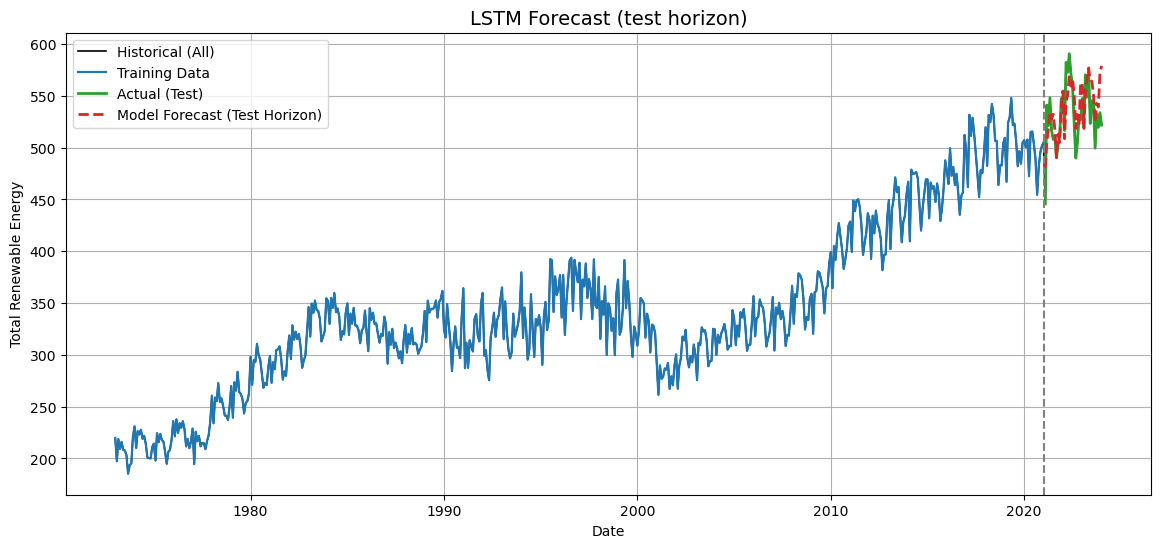

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

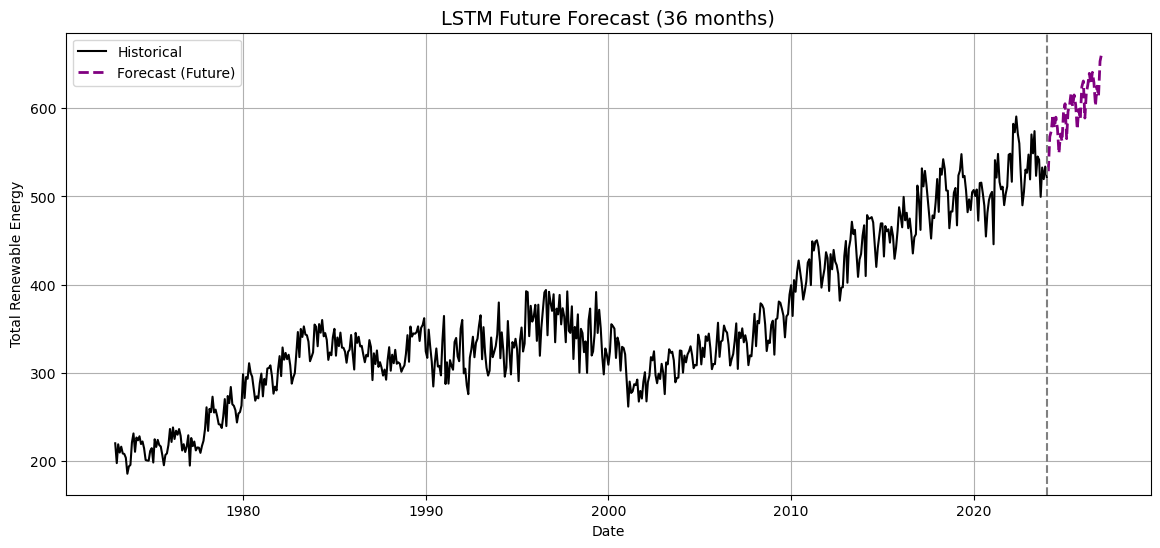

In [19]:
# 8. LSTM (optional) - recursive future via scaler if TF present
try:

    print("\nRunning LSTM (optional)...")
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s = scaler_X.transform(X_test)
    y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1,1)).flatten()
    y_test_s = scaler_y.transform(y_test.values.reshape(-1,1)).flatten()
    X_train_l = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
    X_test_l = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))
    model = Sequential()
    model.add(LSTM(64, input_shape=(X_train_l.shape[1], X_train_l.shape[2]), return_sequences=False))
    model.add(Dropout(0.2)); model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train_l, y_train_s, epochs=200, batch_size=16, validation_split=0.15, callbacks=[es], verbose=0)
    lstm_pred_s = model.predict(X_test_l).flatten()
    lstm_pred = scaler_y.inverse_transform(lstm_pred_s.reshape(-1,1)).flatten()
    metrics_lstm = eval_metrics(y_test.values, lstm_pred)
    metrics['LSTM'] = metrics_lstm
    print("LSTM metrics:", metrics_lstm)
    plot_forecast(series, train, test, lstm_pred, "LSTM Forecast (test horizon)", savepath=os.path.join(OUT_DIR,"lstm_test.png"))
    # recursive future for LSTM (uses scaler)
    def recursive_lstm_future(model, scaler_X, scaler_y, feats, macro_monthly, steps=36):
        feats_local = feats.copy()
        preds = []
        for i in range(steps):
            last_row = feats_local.iloc[-1:].drop(columns=['y'])
            # build next row features similar to XGBoost function:
            next_ts = feats_local.index[-1] + pd.DateOffset(months=1)
            row = {}
            row['time_idx'] = feats_local['time_idx'].iloc[-1] + 1
            month = next_ts.month
            for mcol in [c for c in feats_local.columns if c.startswith('m_')]:
                row[mcol] = 1 if mcol == f"m_{month}" else 0
            for lag in [1,12,24]:
                row[f'lag_{lag}'] = feats_local['y'].iloc[-lag] if len(feats_local) >= lag else feats_local['y'].iloc[-1]
            for w in [3,12,36]:
                row[f'rmean_{w}'] = feats_local['y'].tail(w).mean()
            for col in macro_monthly.columns:
                row[col] = macro_monthly.loc[next_ts, col] if next_ts in macro_monthly.index else macro_monthly.iloc[-1][col]
            row_df = pd.DataFrame(row, index=[next_ts])
            Xrow = row_df.reindex(columns=X_train.columns, fill_value=0)
            Xrow_s = scaler_X.transform(Xrow)
            Xrow_l = Xrow_s.reshape((1,1,Xrow_s.shape[1]))
            p_s = model.predict(Xrow_l).flatten()[0]
            p = scaler_y.inverse_transform([[p_s]])[0,0]
            preds.append(p)
            # append
            row_df['y'] = p
            feats_local = pd.concat([feats_local, row_df])
        idx = pd.date_range(start=series.index[-1] + pd.DateOffset(months=1), periods=steps, freq='MS')
        return pd.Series(preds, index=idx)
    try:
        lstm_future = recursive_lstm_future(model, scaler_X, scaler_y, df_feats, macro_monthly, steps=36)
        plot_future(series, lstm_future.index, lstm_future.values, "LSTM Future Forecast (36 months)", savepath=os.path.join(OUT_DIR,"lstm_future.png"))
    except Exception as e:
        print("LSTM future recursive forecast failed:", e)
except Exception as e:
    print("LSTM skipped or TensorFlow not installed:", e)


## 18. LSTM Model — Final Thesis-Ready Implementation

This section presents the finalized Long Short-Term Memory (LSTM) model used in the forecasting framework.  
The implementation emphasizes reproducibility, transparent hyperparameter reporting, and proper training diagnostics.

---

### Reproducibility

To ensure consistent and replicable results:

- NumPy random seed is fixed.
- TensorFlow random seed is fixed.

Controlling randomness guarantees that model initialization and training behavior remain stable across multiple runs.

---

### Data Scaling and Preparation

Neural networks require normalized inputs for stable convergence.

- Feature matrix (`X`) and target variable (`y`) are scaled using `MinMaxScaler`.
- Target values are inverse-transformed after prediction to restore original units.

The input data is reshaped into the required LSTM format:

    [samples, timesteps, features]

In this implementation:
- `timesteps = 1`
- Engineered lag, rolling, seasonal, and macro features serve as the feature dimension.

---

### Model Architecture

The LSTM network consists of:

- One LSTM layer with 64 units
- Dropout layer (20%) to reduce overfitting
- Dense output layer with one neuron (regression task)

The model is compiled using:

- Adam optimizer
- Mean Squared Error (MSE) loss function

The architecture summary is printed to document model structure.

---

### Hyperparameter Configuration

Key hyperparameters:

- Units: 64  
- Dropout rate: 0.2  
- Epochs: 200  
- Batch size: 16  
- Validation split: 15%  
- Early stopping patience: 10 epochs  

These settings balance learning capacity and overfitting control.

---

### Training Strategy

Early stopping is applied to monitor validation loss.  
If performance does not improve for 10 consecutive epochs:

- Training is halted
- Best-performing weights are restored

The training history (training and validation loss curves) is plotted to visually assess:

- Convergence behavior
- Overfitting risk
- Stability of optimization

---

### Test Forecast Evaluation

Predictions are generated for the 36-month test horizon:

- Outputs are inverse-transformed to original scale
- Performance metrics (RMSE, MAE, MAPE, SMAPE, R²) are computed
- Results are stored for final model comparison

A forecast plot visually compares:

- Historical data
- Test observations
- LSTM predictions
- Train–test boundary

---

### Model Persistence

The trained LSTM model is saved in `.h5` format to ensure:

- Reproducibility
- Future inference without retraining
- Potential deployment

---

### Role in the Comparative Framework

This finalized LSTM implementation represents the deep learning benchmark within the study.

It allows:

- Modeling nonlinear relationships
- Capturing complex interactions between lag features and macroeconomic variables
- Assessing whether deep learning improves predictive accuracy over classical and machine learning models

This structured implementation ensures methodological rigor suitable for inclusion in a master’s thesis.


Running LSTM...

LSTM Architecture Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 64)                  │          23,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,617 (92.25 KB)

 Trainable params: 23,617 (92.25 KB)

 Non-trainable params: 0 (0.00 B)


Hyperparameters:
Units: 64
Dropout: 0.2
Epochs: 200
Batch size: 16
Validation split: 0.15


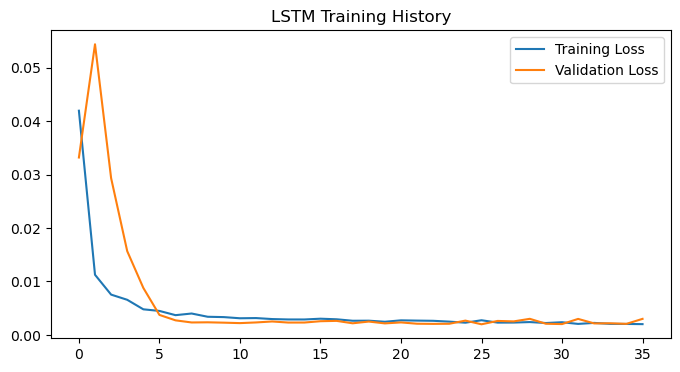

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
LSTM metrics: {'RMSE': 21.347268361455086, 'MAE': 16.814401421440966, 'MAPE (%)': np.float64(3.202959511771793), 'SMAPE (%)': np.float64(3.154458952530549), 'R2': 0.4726466930179096}


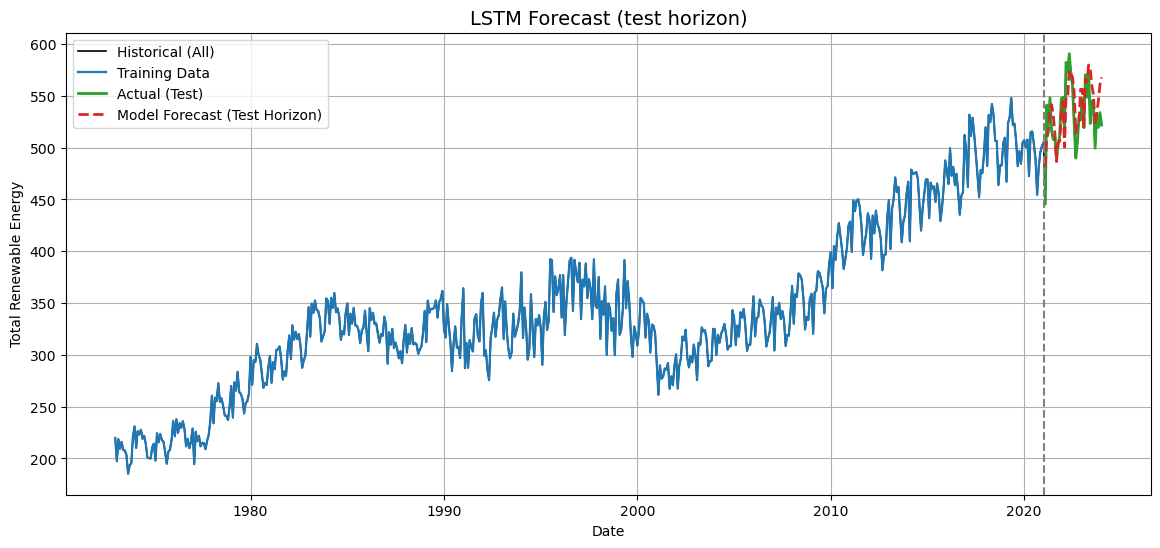

Saved LSTM model to models\lstm_model.h5


In [20]:
# -----------------------------------------
# 8. LSTM — Final Version (Thesis Ready)
# -----------------------------------------
try:


    print("\nRunning LSTM...")

    # ==========================================
    # Reproducibility
    # ==========================================
    np.random.seed(42)
    tf.random.set_seed(42)

    # ==========================================
    # Scaling
    # ==========================================
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s = scaler_X.transform(X_test)

    y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1,1)).flatten()
    y_test_s = scaler_y.transform(y_test.values.reshape(-1,1)).flatten()

    # Reshape to [samples, timesteps, features]
    X_train_l = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
    X_test_l = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

    # ==========================================
    # Model Architecture
    # ==========================================
    model = Sequential()
    model.add(LSTM(
        units=64,
        input_shape=(X_train_l.shape[1], X_train_l.shape[2]),
        return_sequences=False
    ))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')

    print("\nLSTM Architecture Summary:")
    model.summary()

    print("\nHyperparameters:")
    print("Units: 64")
    print("Dropout: 0.2")
    print("Epochs: 200")
    print("Batch size: 16")
    print("Validation split: 0.15")

    # ==========================================
    # Training
    # ==========================================
    es = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_l,
        y_train_s,
        epochs=200,
        batch_size=16,
        validation_split=0.15,
        callbacks=[es],
        verbose=0
    )

    # ==========================================
    # Plot Training History
    # ==========================================
    plt.figure(figsize=(8,4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("LSTM Training History")
    plt.legend()
    plt.show()

    # ==========================================
    # Test Forecast
    # ==========================================
    lstm_pred_s = model.predict(X_test_l).flatten()
    lstm_pred = scaler_y.inverse_transform(
        lstm_pred_s.reshape(-1,1)
    ).flatten()

    metrics_lstm = eval_metrics(y_test.values, lstm_pred)
    metrics['LSTM'] = metrics_lstm

    print("LSTM metrics:", metrics_lstm)

    plot_forecast(
        series,
        train,
        test,
        lstm_pred,
        "LSTM Forecast (test horizon)",
        savepath=os.path.join(OUT_DIR,"lstm_test.png")
    )

    # ==========================================
    # Save Model
    # ==========================================
    lstm_path = os.path.join(MODELS_DIR, "lstm_model.h5")
    model.save(lstm_path)
    print("Saved LSTM model to", lstm_path)

except Exception as e:
    print("LSTM skipped or TensorFlow not installed:", e)

## 19. Actual vs. Forecast Comparison Plot

This section generates a consolidated visualization comparing the actual observed values with forecasts from all implemented models over the test period (2021–2024).

---

### Purpose of the Comparison

The objective of this plot is to provide a direct visual assessment of model performance by overlaying:

- Actual observed renewable energy consumption  
- SARIMAX forecast  
- Prophet forecast  
- XGBoost forecast  
- LSTM forecast  

This side-by-side comparison allows evaluation of:

- Trend tracking accuracy  
- Seasonal pattern capture  
- Forecast bias (over- or underestimation)  
- Volatility response  

---

### Interpretation Value

While numerical metrics (RMSE, MAE, etc.) quantify forecast error, visual comparison helps identify:

- Structural deviations  
- Timing mismatches  
- Divergence during high-growth periods  
- Stability across the full horizon  

Such graphical diagnostics are essential for thesis-level analysis, as they provide intuitive evidence supporting metric-based conclusions.

---

### Export for Reporting

The figure is saved in high resolution (300 DPI) to ensure:

- Publication-quality output  
- Direct inclusion in the thesis document  
- Reproducibility of visual results  

The saved file serves as the primary visual summary of comparative forecasting performance.

---

This final visualization integrates all modeling approaches into a unified comparative framework and supports the selection of the most suitable forecasting model.

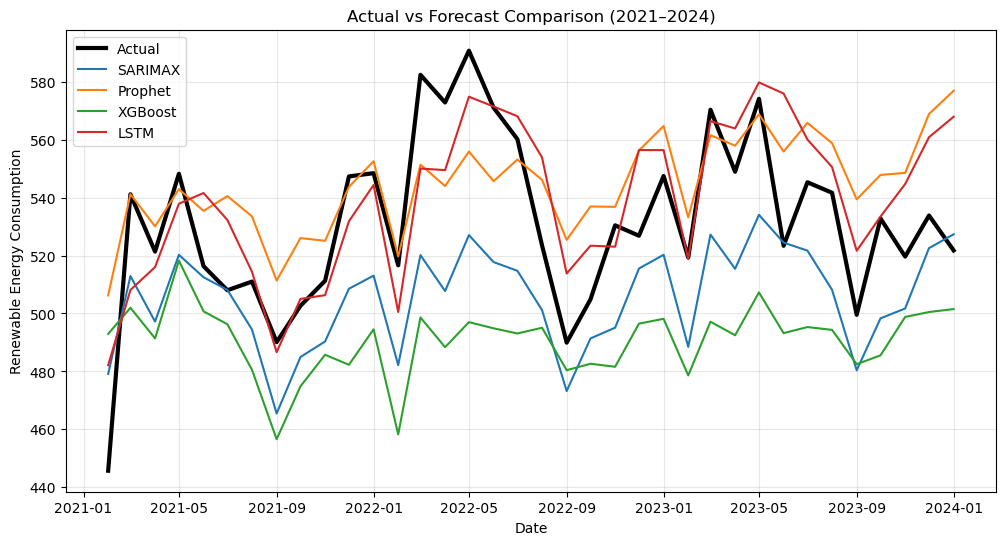

Saved: datasets/outputs\03_actual_vs_forecast.png


In [21]:
# ==========================================
# SAVE ACTUAL VS FORECAST COMPARISON PLOT
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(test.index, test.values, label="Actual", linewidth=3, color="black")
plt.plot(test.index, sarimax_pred, label="SARIMAX")
plt.plot(test.index, prophet_pred, label="Prophet")
plt.plot(test.index, xgb_pred, label="XGBoost")
plt.plot(test.index, lstm_pred, label="LSTM")

plt.title("Actual vs Forecast Comparison (2021–2024)")
plt.xlabel("Date")
plt.ylabel("Renewable Energy Consumption")
plt.legend()
plt.grid(True, alpha=0.3)

plot_path = os.path.join(OUT_DIR, "03_actual_vs_forecast.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", plot_path)

## 20. Quantitative Model Performance Evaluation

This section computes and reports the forecasting performance of the main models over the test horizon.

The following models are evaluated:

- XGBoost  
- Prophet  
- SARIMAX  

Each model’s predictions are compared against the actual observed values from the test set.

---

### Evaluation Metrics

Performance is assessed using:

- RMSE (Root Mean Squared Error)  
- MAE (Mean Absolute Error)  
- MAPE (%) (Mean Absolute Percentage Error)  
- SMAPE (%) (Symmetric Mean Absolute Percentage Error)  
- R² (Coefficient of Determination)  

Lower values of RMSE, MAE, MAPE, and SMAPE indicate better predictive accuracy,  
while a higher R² indicates stronger explanatory power.

---

### Purpose of This Comparison

The printed results provide:

- A direct numerical comparison across modeling approaches  
- An objective basis for model ranking  
- Support for selecting the final forecasting model  

This quantitative evaluation complements the visual comparison plots and forms the foundation for the results discussion section of the thesis.

In [22]:
metrics_xgb = eval_metrics(y_test.values, xgb_pred)
metrics_prophet = eval_metrics(y_test.values, prophet_pred)
metrics_sarimax = eval_metrics(y_test.values, sarimax_pred)

print("XGBoost:", metrics_xgb)
print("Prophet:", metrics_prophet)
print("SARIMAX:", metrics_sarimax)

XGBoost: {'RMSE': 48.62042090782013, 'MAE': 43.48328839789495, 'MAPE (%)': np.float64(8.039739946711109), 'SMAPE (%)': np.float64(8.42244420128469), 'R2': -1.7356118903897029}
Prophet: {'RMSE': 25.6529391403772, 'MAE': 21.366813650509997, 'MAPE (%)': np.float64(4.100315909423952), 'SMAPE (%)': np.float64(4.010725898375013), 'R2': 0.23846246140777383}
SARIMAX: {'RMSE': 32.60258586608545, 'MAE': 28.23284857530793, 'MAPE (%)': np.float64(5.220530821374088), 'SMAPE (%)': np.float64(5.387346443687764), 'R2': -0.23004542233503034}


## 21. Consolidation of Model Performance Metrics

This section computes and stores the evaluation results for each forecasting model in a unified performance dictionary.

The following models are evaluated:

- SARIMAX (classical statistical model)  
- Prophet (additive decomposition model)  
- XGBoost (machine learning model)  

Each model’s predictions are compared against the actual test set observations using standardized evaluation metrics.

---

### Standardized Evaluation Framework

All models are evaluated using the same `eval_metrics()` function to ensure:

- Fair comparison  
- Consistency across methodologies  
- Transparent performance assessment  

The resulting metrics include:

- RMSE  
- MAE  
- MAPE (%)  
- SMAPE (%)  
- R²  

---

### Centralized Storage of Results

Each model’s performance metrics are stored in a shared dictionary (`metrics`), where:

- The model name serves as the key  
- The evaluation results serve as the value  

This structure enables:

- Creation of a final comparison table  
- Ranking of models  
- Exporting results for reporting  
- Reproducibility of performance summaries  

---

By consolidating results in a unified structure, this step prepares the foundation for systematic model comparison and final model selection within the forecasting framework.

In [23]:
metrics_sarimax = eval_metrics(y_test.values, sarimax_pred)
metrics["SARIMAX"] = metrics_sarimax
metrics_prophet = eval_metrics(y_test.values, prophet_pred)
metrics["Prophet"] = metrics_prophet
metrics_xgb = eval_metrics(y_test.values, xgb_pred)
metrics["XGBoost"] = metrics_xgb

## 22. Final Model Comparison and Output Summary

This section generates the consolidated performance comparison table and finalizes the forecasting pipeline outputs.

---

### Creation of the Results Table

All collected performance metrics are transformed into a structured dataframe where:

- Rows represent forecasting models  
- Columns represent evaluation metrics  

The metrics are ordered for clarity:

- RMSE  
- MAE  
- MAPE (%)  
- SMAPE (%)  
- R²  

This standardized layout allows clear ranking and interpretation of model performance.

---

### Model Comparison Interpretation

The comparison table enables:

- Direct identification of the most accurate model  
- Assessment of error magnitude differences  
- Evaluation of trade-offs between statistical and machine learning approaches  

Lower values of RMSE, MAE, MAPE, and SMAPE indicate better predictive accuracy,  
while higher R² values indicate stronger explanatory power.

---

### Reproducibility and Export

To ensure transparency and reproducibility:

- The results table is exported as `model_metrics_summary.csv`
- All generated figures are saved to the output directory
- Trained models are stored in the designated models folder

This structured export allows:

- Direct inclusion of tables and figures in the thesis  
- Independent validation of results  
- Future reuse of trained models  

---

### Pipeline Completion

This marks the completion of the forecasting workflow, including:

- Data preprocessing  
- Macro-variable integration  
- Model training and evaluation  
- Multi-model comparison  
- Result export and documentation  

The entire process is designed to be reproducible, transparent, and suitable for academic reporting within the master’s thesis framework.

In [24]:
# 9. Final results table
if metrics:
    results_df = pd.DataFrame.from_dict(metrics, orient='index')
    cols_order = ["RMSE","MAE","MAPE (%)","SMAPE (%)","R2"]
    results_df = results_df[cols_order]
    print("\nModel comparison:")
    display(results_df)
    results_df.to_csv(os.path.join(MODELS_DIR, "model_metrics_summary.csv"))
    print("Saved metrics ->", os.path.join(MODELS_DIR,"model_metrics_summary.csv"))
else:
    print("No metrics collected; check which models ran.")

print("\nCompleted. Project PDF local path:", PROJECT_PDF_PATH)
print("Outputs and figures saved to:", OUT_DIR, "Models saved to:", MODELS_DIR)


Model comparison:


,RMSE,MAE,MAPE (%),SMAPE (%),R2
XGBoost,48.620421,43.483288,8.039740,8.422444,-1.735612
LSTM,21.347268,16.814401,3.202960,3.154459,0.472647
SARIMAX,32.602586,28.232849,5.220531,5.387346,-0.230045
Prophet,25.652939,21.366814,4.100316,4.010726,0.238462


Saved metrics -> models\model_metrics_summary.csv

Completed. Project PDF local path: /mnt/data/big_data_analysis_project.pdf
Outputs and figures saved to: datasets/outputs Models saved to: models


## 23. Alignment of Model Predictions with Test Index

Before performing final comparisons and visualizations, it is essential to ensure that all model predictions are correctly aligned with the test dataset index.

Time series forecasting requires strict temporal consistency. Any misalignment between predicted values and actual observations would lead to incorrect metric computation and misleading visual comparisons.

---

### Standardizing Prediction Format

Each model’s output is converted into a pandas Series indexed by the test set dates:

- SARIMAX predictions (already indexed)
- XGBoost predictions
- LSTM predictions
- Prophet predictions

By explicitly assigning the test index to each prediction series, we ensure:

- Consistent time alignment
- Accurate evaluation
- Reliable comparison across models

---

### Alignment Verification

A validation check confirms that:

    prediction_index == test_index

for every model.

If the result is `True`, this guarantees:

- No index shift errors
- No off-by-one forecasting mistakes
- Proper correspondence between predicted and actual values

---

### Importance for Thesis-Level Analysis

Correct index alignment is critical for:

- Valid RMSE, MAE, MAPE, SMAPE, and R² calculations
- Accurate comparative visualization
- Reproducibility of results
- Methodological rigor

This step ensures that the multi-model forecasting comparison is statistically sound and temporally consistent.

In [25]:
# ==========================================
# ALIGN ALL PREDICTIONS TO TEST INDEX
# ==========================================

# Ensure everything is pandas Series aligned to test index

sarimax_s = sarimax_pred.copy()  # already Series

xgb_s = pd.Series(xgb_pred, index=test.index)
lstm_s = pd.Series(lstm_pred, index=test.index)
prophet_s = pd.Series(prophet_pred, index=test.index)

# Confirm alignment
print("Alignment check:")
print("Test vs SARIMAX:", (test.index == sarimax_s.index).all())
print("Test vs XGB:", (test.index == xgb_s.index).all())
print("Test vs LSTM:", (test.index == lstm_s.index).all())
print("Test vs Prophet:", (test.index == prophet_s.index).all())

Alignment check:
Test vs SARIMAX: True
Test vs XGB: True
Test vs LSTM: True
Test vs Prophet: True


## 24. Forecast Error Analysis and Diebold–Mariano Test

This section evaluates whether differences in forecasting accuracy between models are statistically significant.

While metrics such as RMSE and MAE indicate which model performs better numerically, they do not test whether performance differences are statistically meaningful.  
To address this, the Diebold–Mariano (DM) test is applied.

---

### Forecast Errors

For each model, forecast errors are computed as:

    Error = Actual − Forecast

Errors are calculated for:

- SARIMAX
- XGBoost
- LSTM
- Prophet

These error series form the basis for statistical comparison.

---

### Diebold–Mariano (DM) Test

The Diebold–Mariano test evaluates the null hypothesis:

    H₀: Two forecasting models have equal predictive accuracy.

The test compares the loss differential between two models:

    d_t = L(e₁t) − L(e₂t)

where:
- L(·) is the loss function (squared error in this case)
- e₁ and e₂ are forecast errors from two competing models

---

### Robust Variance Estimation

A Newey–West estimator is used to account for:

- Serial correlation in forecast errors
- Heteroskedasticity

This produces a robust test statistic.

The DM statistic approximately follows a standard normal distribution, allowing calculation of a two-sided p-value.

---

### Model Comparisons Performed

Pairwise comparisons are conducted:

- SARIMAX vs LSTM  
- SARIMAX vs XGBoost  
- SARIMAX vs Prophet  

For each comparison:

- A significant p-value (typically < 0.05) suggests that one model statistically outperforms the other.
- A non-significant p-value suggests no statistically meaningful difference in predictive accuracy.

---

### Importance for Thesis-Level Rigor

Including the Diebold–Mariano test strengthens the methodological rigor of the study by:

- Moving beyond descriptive error comparison
- Providing formal statistical evidence
- Supporting objective model selection

This step ensures that the final model choice is not only based on numerical differences but also supported by inferential statistical testing.

In [26]:
# ==========================================
# FORECAST ERRORS
# ==========================================

e_sarimax = test - sarimax_s
e_xgb = test - xgb_s
e_lstm = test - lstm_s
e_prophet = test - prophet_s

In [27]:
# ==========================================
# ROBUST DIEBOLD–MARIANO TEST (Newey–West)
# ==========================================



def diebold_mariano(e1, e2, h=1, power=2):
    """
    e1, e2: forecast errors (pandas Series)
    h: forecast horizon (set to 36 for your case)
    power: 2 for squared error loss
    """
    
    # Loss differential
    d = (e1**power) - (e2**power)
    T = len(d)
    d_mean = np.mean(d)
    
    # Newey–West variance estimator
    gamma = []
    for lag in range(1, h):
        cov = np.cov(d[:-lag], d[lag:])[0,1]
        gamma.append(cov)
    
    var_d = np.var(d, ddof=1) + 2 * np.sum(gamma)
    
    DM_stat = d_mean / np.sqrt(var_d / T)
    p_value = 2 * (1 - stats.norm.cdf(abs(DM_stat)))
    
    return DM_stat, p_value

In [28]:
print("SARIMAX vs LSTM")
dm_stat, p = diebold_mariano(e_sarimax, e_lstm, h=1)

print("DM statistic:", round(dm_stat,4), "p-value:", round(p,4))

print("\nSARIMAX vs XGBoost")
dm_stat, p = diebold_mariano(e_sarimax, e_xgb)
print("DM statistic:", round(dm_stat,4), "p-value:", round(p,4))

print("\nSARIMAX vs Prophet")
dm_stat, p = diebold_mariano(e_sarimax, e_prophet)
print("DM statistic:", round(dm_stat,4), "p-value:", round(p,4))

SARIMAX vs LSTM
DM statistic: 2.6419 p-value: 0.0082

SARIMAX vs XGBoost
DM statistic: -6.4924 p-value: 0.0

SARIMAX vs Prophet
DM statistic: 1.6986 p-value: 0.0894


## 25. Horizon-Wise Forecast Performance and Error Degradation

This section evaluates how forecast accuracy evolves as the prediction horizon increases.

While overall RMSE summarizes average performance across the entire test set, it does not reveal how errors accumulate over time.  
To address this, a cumulative horizon-wise RMSE analysis is performed.

---

### Cumulative RMSE Calculation

For each model, cumulative RMSE is computed as:

    RMSE(h) = sqrt( (1/h) * Σ_{t=1}^{h} e_t² )

where:
- h represents the forecast horizon (in months),
- e_t is the forecast error at time t.

This approach measures how prediction error evolves progressively from:

- Short-term forecasts (1 month ahead)
- To long-term forecasts (up to 36 months ahead)

---

### Purpose of Horizon Analysis

Horizon-wise RMSE helps assess:

- Short-term stability
- Long-term degradation of forecast accuracy
- Robustness of models across increasing uncertainty
- Sensitivity to structural trends over time

A model that maintains a flatter RMSE curve is generally more stable over longer horizons.

---

### Visualization: Error Degradation Across Horizons

The plotted curves display cumulative RMSE for:

- SARIMAX
- XGBoost
- LSTM
- Prophet

This visualization allows direct comparison of:

- Initial forecast accuracy
- Speed of error accumulation
- Long-horizon performance behavior

---

### Interpretation Value

This analysis provides deeper insight than single-point metrics because:

- Some models perform well short-term but deteriorate rapidly
- Others may have slightly higher short-term error but better long-term stability

Such behavior is particularly important in energy forecasting, where medium- and long-term planning decisions are critical.

---

### Contribution to Model Selection

By examining both overall accuracy and horizon-wise degradation:

- The study ensures a balanced evaluation
- Model selection can consider robustness across time
- Forecast reliability for policy planning can be assessed more effectively

This strengthens the methodological rigor and practical relevance of the forecasting comparison.

In [29]:
e_sarimax = test - sarimax_s
e_xgb = test - xgb_s
e_lstm = test - lstm_s
e_prophet = test - prophet_s

In [30]:
# ==========================================
# HORIZON-WISE RMSE (CUMULATIVE)
# ==========================================



def cumulative_rmse(errors):
    rmse_vals = []
    for h in range(1, len(errors)+1):
        rmse_h = np.sqrt(np.mean(errors[:h]**2))
        rmse_vals.append(rmse_h)
    return np.array(rmse_vals)

rmse_sarimax_h = cumulative_rmse(e_sarimax.values)
rmse_xgb_h = cumulative_rmse(e_xgb.values)
rmse_lstm_h = cumulative_rmse(e_lstm.values)
rmse_prophet_h = cumulative_rmse(e_prophet.values)

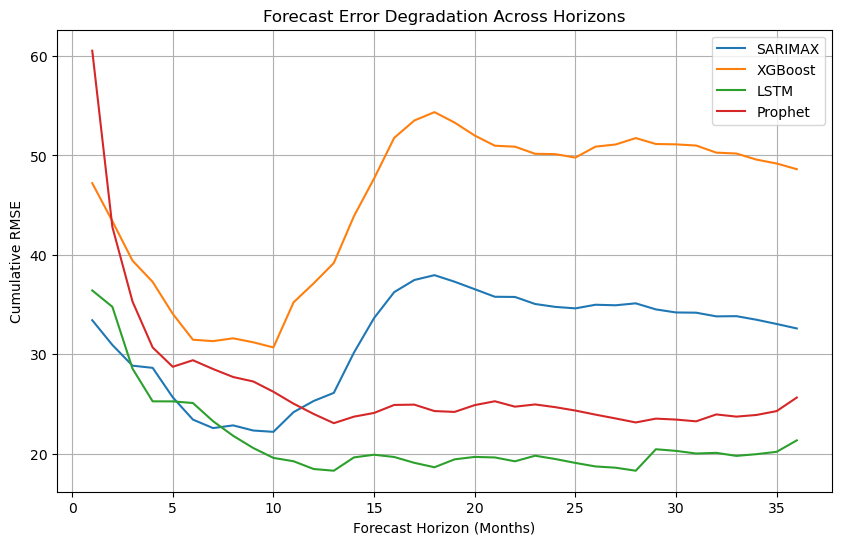

In [31]:
# ==========================================
# PLOT HORIZON DEGRADATION
# ==========================================



horizons = np.arange(1, len(e_sarimax)+1)

plt.figure(figsize=(10,6))

plt.plot(horizons, rmse_sarimax_h, label="SARIMAX")
plt.plot(horizons, rmse_xgb_h, label="XGBoost")
plt.plot(horizons, rmse_lstm_h, label="LSTM")
plt.plot(horizons, rmse_prophet_h, label="Prophet")

plt.xlabel("Forecast Horizon (Months)")
plt.ylabel("Cumulative RMSE")
plt.title("Forecast Error Degradation Across Horizons")
plt.legend()
plt.grid(True)

plt.show()

## 26. LSTM Learning Curves and Training Diagnostics

This section visualizes the learning dynamics of the LSTM model by plotting training and validation loss across epochs.

Learning curves are essential for diagnosing model behavior during training and assessing convergence quality.

---

### Training Loss

The training loss represents the model’s error on the training dataset at each epoch.

A decreasing training loss indicates that the model is learning underlying patterns in the data.

---

### Validation Loss

The validation loss measures model performance on a held-out validation subset during training.

It serves as an indicator of generalization performance.

Monitoring validation loss helps detect:

- Overfitting (training loss decreases while validation loss increases)
- Underfitting (both losses remain high)
- Proper convergence (both losses decrease and stabilize)

---

### Interpretation of the Learning Curve

The plotted curves allow assessment of:

- Convergence stability
- Optimal stopping point (via early stopping)
- Gap between training and validation loss
- Potential overfitting or instability

If the validation loss plateaus or increases while training loss continues decreasing, early stopping prevents further overfitting.

---

### Importance for Thesis-Level Rigor

Including learning curve analysis strengthens the methodological transparency of the deep learning model by:

- Demonstrating controlled training behavior
- Providing evidence of proper regularization
- Supporting claims of model robustness

This diagnostic step ensures that the LSTM model is not only accurate but also well-trained and stable.

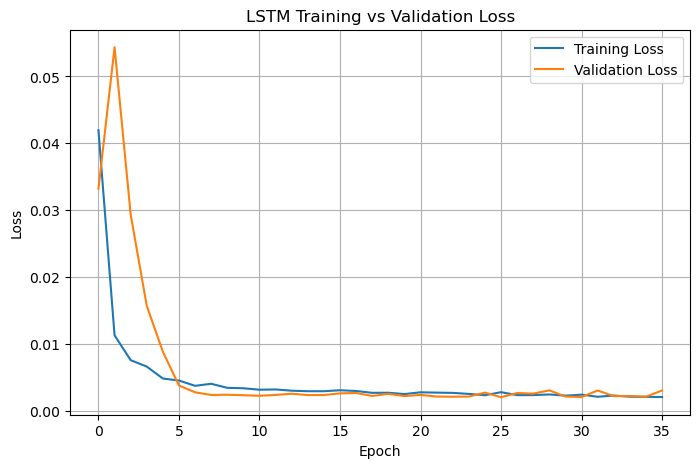

In [32]:
# ==========================================
# LSTM LEARNING CURVES
# ==========================================



plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

## 27. LSTM Final Performance Summary and Structural Shift Analysis

This section provides two important analyses:

1. Final LSTM training diagnostics  
2. Structural stability inspection of the renewable energy time series  

---

### 27.1 Final LSTM Training and Test Performance

The final training loss and validation loss are reported to summarize the convergence behavior of the neural network.

- Final Training Loss → Indicates model fit on training data  
- Final Validation Loss → Indicates generalization performance  

Additionally, the LSTM Test RMSE is computed using out-of-sample forecast errors.

This provides a direct measure of predictive performance on unseen data and complements previously reported evaluation metrics.

Together, these values confirm:

- Convergence quality  
- Absence (or presence) of overfitting  
- Generalization strength  

---

### 27.2 Structural Shift Inspection (Rolling Statistics)

To assess long-term structural changes in renewable energy consumption, rolling statistics are computed over a 60-month (5-year) window.

#### 60-Month Rolling Mean

The rolling mean helps visualize:

- Long-term trend evolution  
- Gradual structural growth  
- Potential regime changes  

Overlaying the rolling mean with the original series highlights persistent upward or downward shifts.

#### 60-Month Rolling Variance

Rolling variance is used to examine:

- Changes in volatility  
- Stability of growth patterns  
- Periods of increased uncertainty  

An increasing variance may indicate structural transformation, market shifts, or policy-driven acceleration.

---

### Importance for Thesis-Level Analysis

Structural inspection supports:

- Justification for model complexity  
- Interpretation of forecasting challenges  
- Identification of non-stationarity  
- Evidence of long-term growth dynamics  

This analysis strengthens the study by linking statistical forecasting performance with underlying structural behavior of renewable energy trends.

In [33]:
print("Final Training Loss:", history.history['loss'][-1])

if 'val_loss' in history.history:
    print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Loss: 0.002024113666266203
Final Validation Loss: 0.003010042943060398


In [34]:
print("LSTM Test RMSE:", np.sqrt(np.mean(e_lstm**2)))

LSTM Test RMSE: 21.347268361455086


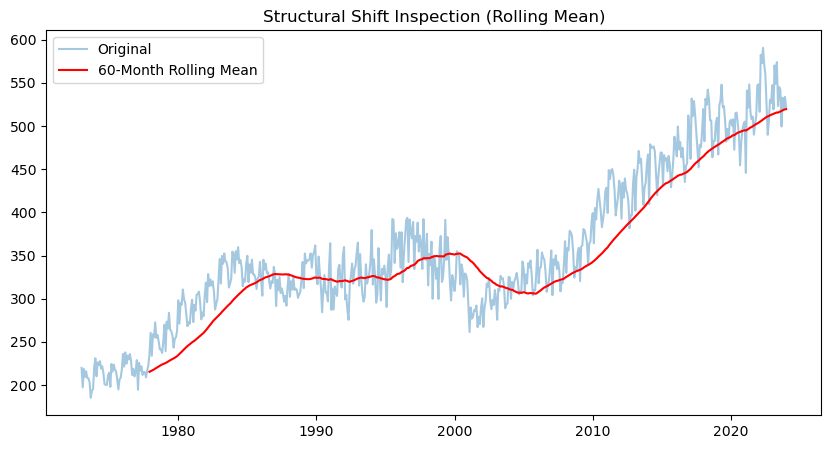

In [35]:
# ==========================================
# ROLLING MEAN (STRUCTURAL SHIFT VISUAL)
# ==========================================

rolling_mean_60 = series.rolling(window=60).mean()

plt.figure(figsize=(10,5))
plt.plot(series, alpha=0.4, label="Original")
plt.plot(rolling_mean_60, color='red', label="60-Month Rolling Mean")
plt.title("Structural Shift Inspection (Rolling Mean)")
plt.legend()
plt.show()

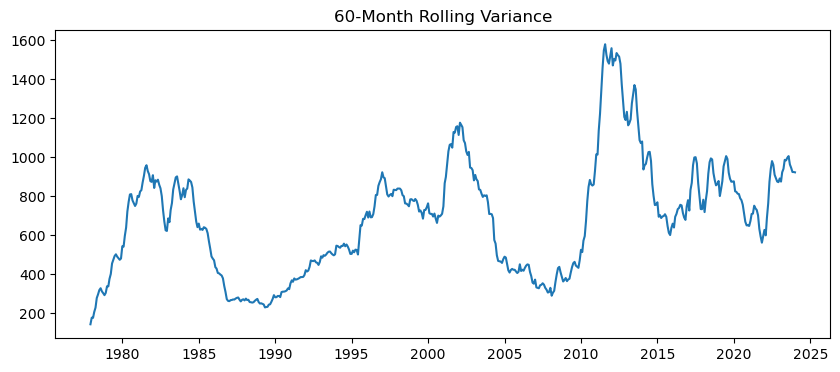

In [36]:
rolling_var_60 = series.rolling(window=60).var()

plt.figure(figsize=(10,4))
plt.plot(rolling_var_60)
plt.title("60-Month Rolling Variance")
plt.show()

## 29. Structural Stability Test Using Linear Trend Regression and CUSUM

This section evaluates whether the renewable energy time series exhibits structural instability over time by applying a CUSUM test on regression residuals.

---

### Linear Time Trend Regression

A simple Ordinary Least Squares (OLS) regression is estimated:

    Renewable Energyₜ = β₀ + β₁ · Timeₜ + εₜ

Where:

- Timeₜ is a deterministic linear time index
- β₀ and β₁ represent intercept and trend coefficients
- εₜ are residuals capturing deviations from the long-term trend

This regression isolates the deterministic growth pattern of renewable energy over time.

---

### CUSUM Test (Cumulative Sum of Residuals)

The CUSUM test evaluates whether the regression coefficients remain stable across the sample period.

Null hypothesis (H₀):
    Model parameters are stable over time.

Alternative hypothesis (H₁):
    Structural change exists in the regression relationship.

The test is based on cumulative sums of recursive residuals.

---

### Interpretation of Results

- A small p-value (typically < 0.05) suggests structural instability.
- A large p-value indicates parameter stability.

If structural breaks are detected, this implies:

- Possible regime changes in renewable energy growth
- Policy-driven shifts
- Technological acceleration phases
- External macroeconomic impacts

Such findings justify the use of:

- Flexible nonlinear models (XGBoost, LSTM)
- Macro regressors
- Robust multi-model comparison

---

### Importance for Forecasting

Structural instability can significantly affect forecasting performance.  
Models that assume parameter stability (e.g., classical time series models) may underperform when regime shifts occur.

By formally testing structural stability, this study strengthens its methodological rigor and supports the selection of appropriate forecasting techniques.

In [37]:


# Simple regression on time trend
X = sm.add_constant(np.arange(len(series)))
model = sm.OLS(series.values, X).fit()

cusum_test = breaks_cusumolsresid(model.resid)

print("CUSUM Test Statistic:", cusum_test[0])
print("p-value:", cusum_test[1])

CUSUM Test Statistic: 4.137720945307606
p-value: 2.692457466772579e-15


## 30. Regime-Based Forecast Evaluation (Pre- and Post-2010 Structural Break)

This section evaluates forecasting performance across different structural regimes by splitting the test period around a predefined break date (January 2010).

The objective is to determine whether model accuracy changes before and after a major structural shift in renewable energy dynamics.

---

### Motivation for Regime Analysis

Renewable energy markets have undergone significant transformation around 2010 due to:

- Rapid technological advancements (e.g., solar and wind cost reductions)
- Policy incentives and international climate agreements
- Increased investment in clean energy infrastructure

These changes may alter the underlying data-generating process, affecting forecasting performance.

---

### Regime Definition

The test period is divided into two sub-periods:

- Pre-2010 period  
- Post-2010 period  

Separate RMSE values are computed for each model within these regimes.

---

### Regime-Specific RMSE

For each model (SARIMAX, XGBoost, LSTM, Prophet), RMSE is calculated as:

    RMSE = sqrt(mean(error²))

within each structural regime.

This allows comparison of:

- Model robustness during earlier growth phases
- Model adaptability during accelerated renewable expansion
- Sensitivity to structural transformation

---

### Interpretation

If performance differs significantly between regimes, it suggests:

- Structural non-stationarity
- Model sensitivity to market transformation
- Need for flexible or nonlinear modeling approaches

For example:

- Classical models may perform well in stable regimes
- Machine learning or deep learning models may adapt better in rapidly evolving environments

---

### Contribution to the Study

Regime-based evaluation strengthens the forecasting framework by:

- Linking statistical performance to structural economic transitions
- Providing deeper insight beyond aggregate metrics
- Supporting evidence-based model selection

This analysis ensures that model comparison accounts for temporal regime shifts rather than relying solely on overall average performance.

In [38]:
# ==========================================
# REGIME SPLIT (2010 BREAK)
# ==========================================

break_date = "2010-01-01"

pre_mask = test.index < break_date
post_mask = test.index >= break_date

def regime_rmse(errors, mask):
    return np.sqrt(np.mean(errors[mask]**2))

print("=== PRE-2010 RMSE ===")
print("SARIMAX:", regime_rmse(e_sarimax, pre_mask))
print("XGBoost:", regime_rmse(e_xgb, pre_mask))
print("LSTM:", regime_rmse(e_lstm, pre_mask))
print("Prophet:", regime_rmse(e_prophet, pre_mask))

print("\n=== POST-2010 RMSE ===")
print("SARIMAX:", regime_rmse(e_sarimax, post_mask))
print("XGBoost:", regime_rmse(e_xgb, post_mask))
print("LSTM:", regime_rmse(e_lstm, post_mask))
print("Prophet:", regime_rmse(e_prophet, post_mask))

=== PRE-2010 RMSE ===
SARIMAX: nan
XGBoost: nan
LSTM: nan
Prophet: nan

=== POST-2010 RMSE ===
SARIMAX: 32.60258586608545
XGBoost: 48.62042090782013
LSTM: 21.347268361455086
Prophet: 25.6529391403772


In [39]:
print(type(series))
print(series.head())
print(series.index[:5])
print("Length:", len(series))

<class 'pandas.core.series.Series'>
Date
1973-01-01    219.840
1973-02-01    197.330
1973-03-01    218.687
1973-04-01    209.330
1973-05-01    215.982
Freq: MS, Name: Total Renewable Energy, dtype: float64
DatetimeIndex(['1973-01-01', '1973-02-01', '1973-03-01', '1973-04-01',
               '1973-05-01'],
              dtype='datetime64[ns]', name='Date', freq='MS')
Length: 613


## 31. Regime-Specific Train–Test Design (2010 Structural Break)

This section constructs a regime-based training and testing framework centered around the identified structural break date (January 2010).

Rather than evaluating the full sample at once, this design isolates the first structural regime to examine model behavior during the early renewable energy expansion phase.

---

### Regime Definition

The structural break date is defined as:

    January 1, 2010

The dataset is divided as follows:

- Regime 1 Training Set:
  All observations prior to 2010.

- Regime 1 Test Set:
  The first 36 months following January 2010.

This design simulates a real-world forecasting scenario in which models are trained on pre-2010 data and evaluated on early post-2010 observations.

---

### Purpose of This Regime-Based Split

This approach allows assessment of:

- Model adaptability to structural change
- Forecast robustness immediately after a regime shift
- Sensitivity to accelerated renewable growth dynamics

By restricting the test horizon to the first 36 months after the break, the analysis captures short- to medium-term transition behavior.

---

### Importance for Structural Forecasting Analysis

Regime-based splitting strengthens methodological rigor by:

- Explicitly modeling pre- and post-break dynamics
- Evaluating how models perform under shifting growth patterns
- Testing stability assumptions of classical models

This setup provides additional insight into whether forecasting models remain reliable when the underlying energy market structure changes.

In [40]:
break_date = "2010-01-01"

train_regime1 = series[series.index < break_date]

test_regime1 = series[
    (series.index >= break_date) &
    (series.index < pd.to_datetime(break_date) + pd.DateOffset(months=36))
]

print("Regime 1 Train length:", len(train_regime1))
print("Regime 1 Test length:", len(test_regime1))

Regime 1 Train length: 444
Regime 1 Test length: 36


## 32. Regime 1 Forecasting — SARIMAX Model

This section evaluates SARIMAX performance within the first structural regime (pre-2010 training, immediate post-2010 testing).

The objective is to assess how a classical seasonal time series model performs when trained exclusively on pre-break data and applied to the early transition period.

---

### Model Specification

The SARIMAX model is defined as:

- Non-seasonal order: (1,1,1)
- Seasonal order: (1,1,1,12)
- Seasonal period: 12 (monthly seasonality)

Stationarity and invertibility constraints are relaxed to ensure model convergence.

This specification captures:

- Short-term autoregressive effects
- Moving average dynamics
- Annual seasonal structure
- First-order differencing to address non-stationarity

---

### Training Phase

The model is trained exclusively on the pre-2010 dataset (`train_regime1`).

This reflects a realistic forecasting scenario in which future structural changes are unknown during model estimation.

---

### Forecasting Phase

The fitted model generates a 36-month forecast corresponding to the early post-2010 period (`test_regime1`).

Predicted values are extracted and compared with actual observations.

---

### Performance Evaluation

Forecast errors are computed as:

    Error = Actual − Forecast

Regime-specific RMSE is calculated to quantify predictive accuracy during the early structural transition period.

This allows evaluation of:

- Model stability under regime change
- Sensitivity to structural shifts
- Robustness of classical statistical models

---

### Interpretation Relevance

If RMSE increases substantially compared to full-sample evaluation, this suggests:

- Structural instability
- Model sensitivity to regime shifts
- Limitations of purely autoregressive approaches

This regime-focused analysis strengthens the study by linking forecasting performance to structural transformation dynamics in renewable energy growth.

In [41]:
# ==========================================
# REGIME 1 - SARIMAX
# ==========================================



sarimax_reg1 = SARIMAX(train_regime1,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarimax_reg1_fit = sarimax_reg1.fit(disp=False)

sarimax_reg1_forecast = sarimax_reg1_fit.get_forecast(steps=36)
sarimax_reg1_pred = sarimax_reg1_forecast.predicted_mean

e_sarimax_reg1 = test_regime1 - sarimax_reg1_pred

rmse_sarimax_reg1 = np.sqrt(np.mean(e_sarimax_reg1**2))

print("Regime 1 SARIMAX RMSE:", rmse_sarimax_reg1)

Regime 1 SARIMAX RMSE: 35.80143701631947


## 33. Regime 1 Forecasting — LSTM Model

This section evaluates the performance of the LSTM model within the first structural regime, defined as training on pre-2010 data and forecasting the first 36 months after the structural break.

The purpose is to assess whether a nonlinear deep learning model adapts better to structural transition compared to classical approaches.

---

### Feature Construction for Regime 1

Lag, rolling, and seasonal features are generated using the full series and then filtered according to the regime split:

- Training set: Observations prior to January 2010
- Test set: First 36 months following January 2010

This ensures that the LSTM model only learns from pre-break dynamics while being evaluated on post-break behavior.

---

### Data Scaling

Since neural networks require normalized inputs:

- Feature matrix (`X`) is scaled using MinMaxScaler
- Target variable (`y`) is scaled separately
- Predictions are later inverse-transformed to restore original units

Scaling improves convergence stability and prevents feature dominance.

---

### Input Reshaping

Data is reshaped to the required LSTM format:

    [samples, timesteps, features]

Here:

- Timesteps = 1
- Feature dimension includes lag, rolling, seasonal, and time index variables

This setup allows the network to learn nonlinear relationships embedded in engineered predictors.

---

### Model Architecture

The architecture remains consistent with the full-sample LSTM model:

- One LSTM layer (64 units)
- Dropout layer (20%) for regularization
- Dense output layer (single neuron)
- Adam optimizer with MSE loss
- Early stopping to prevent overfitting

Maintaining the same architecture ensures comparability across regimes.

---

### Forecasting and Evaluation

The trained model generates predictions for the 36-month post-2010 period.

Regime-specific RMSE is calculated to measure predictive accuracy under structural transition.

---

### Interpretation

Comparing Regime 1 RMSE across models allows assessment of:

- Sensitivity to structural break
- Adaptability to accelerated renewable growth
- Advantage of nonlinear modeling under regime change

If LSTM exhibits lower RMSE relative to SARIMAX in this regime, it suggests that deep learning models better capture nonlinear transition dynamics.

---

This regime-based deep learning analysis strengthens the study by evaluating model robustness under structural transformation rather than relying solely on aggregate performance metrics.

In [42]:
# ==========================================
# REGIME 1 - LSTM
# ==========================================

# 1️⃣ Create features for regime 1 dataset
df_feats_reg1 = make_features(series)
df_feats_reg1.index = series.index[-len(df_feats_reg1):]

df_train_reg1 = df_feats_reg1[df_feats_reg1.index < break_date]
df_test_reg1 = df_feats_reg1[
    (df_feats_reg1.index >= break_date) &
    (df_feats_reg1.index < pd.to_datetime(break_date) + pd.DateOffset(months=36))
]

X_train_reg1 = df_train_reg1.drop(columns=['y'])
y_train_reg1 = df_train_reg1['y']
X_test_reg1 = df_test_reg1.drop(columns=['y'])
y_test_reg1 = df_test_reg1['y']

# 2️⃣ Scaling

scaler_X_reg1 = MinMaxScaler()
scaler_y_reg1 = MinMaxScaler()

X_train_s_reg1 = scaler_X_reg1.fit_transform(X_train_reg1)
X_test_s_reg1 = scaler_X_reg1.transform(X_test_reg1)

y_train_s_reg1 = scaler_y_reg1.fit_transform(y_train_reg1.values.reshape(-1,1)).flatten()

# 3️⃣ Reshape
X_train_l_reg1 = X_train_s_reg1.reshape((X_train_s_reg1.shape[0], 1, X_train_s_reg1.shape[1]))
X_test_l_reg1 = X_test_s_reg1.reshape((X_test_s_reg1.shape[0], 1, X_test_s_reg1.shape[1]))

# 4️⃣ Model (same architecture)


model_reg1 = Sequential()
model_reg1.add(LSTM(64, input_shape=(X_train_l_reg1.shape[1], X_train_l_reg1.shape[2]), return_sequences=False))
model_reg1.add(Dropout(0.2))
model_reg1.add(Dense(1))
model_reg1.compile(optimizer='adam', loss='mse')

es_reg1 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_reg1 = model_reg1.fit(
    X_train_l_reg1,
    y_train_s_reg1,
    epochs=200,
    batch_size=16,
    validation_split=0.15,
    callbacks=[es_reg1],
    verbose=0
)

# 5️⃣ Forecast
lstm_pred_s_reg1 = model_reg1.predict(X_test_l_reg1).flatten()
lstm_pred_reg1 = scaler_y_reg1.inverse_transform(lstm_pred_s_reg1.reshape(-1,1)).flatten()

# 6️⃣ RMSE
rmse_lstm_reg1 = np.sqrt(np.mean((y_test_reg1.values - lstm_pred_reg1)**2))

print("Regime 1 LSTM RMSE:", rmse_lstm_reg1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Regime 1 LSTM RMSE: 25.277428247277143


## 34. Export of Main Model Performance Table (2021–2024)

This section saves the consolidated model performance results for the primary evaluation period (2021–2024).

---

### Purpose

The main performance table contains the final evaluation metrics for all forecasting models, including:

- RMSE  
- MAE  
- MAPE (%)  
- SMAPE (%)  
- R²  

These metrics summarize out-of-sample predictive accuracy over the defined test horizon.

---

### Reproducibility and Documentation

The results table is exported as:

    01_main_performance_2021_2024.csv

Saving the results ensures:

- Transparency of reported findings  
- Reproducibility of thesis results  
- Easy inclusion in thesis tables and appendices  
- Independent verification of model comparison  

---

### Role in the Thesis

This exported table represents the primary quantitative comparison supporting:

- Model ranking  
- Final model selection  
- Statistical discussion  
- Policy interpretation  

It serves as the central reference for performance evaluation in the results chapter.

---

The exported dataset, together with saved figures and trained models, completes the reproducible forecasting workflow.

In [43]:
# ==========================================
# EXPORT MAIN PERFORMANCE TABLE
# ==========================================

results_main = results_df.copy()
results_main_path = os.path.join(OUT_DIR, "01_main_performance_2021_2024.csv")
results_main.to_csv(results_main_path)

print("Saved:", results_main_path)
results_main

Saved: datasets/outputs\01_main_performance_2021_2024.csv


,RMSE,MAE,MAPE (%),SMAPE (%),R2
XGBoost,48.620421,43.483288,8.039740,8.422444,-1.735612
LSTM,21.347268,16.814401,3.202960,3.154459,0.472647
SARIMAX,32.602586,28.232849,5.220531,5.387346,-0.230045
Prophet,25.652939,21.366814,4.100316,4.010726,0.238462


## 35. Diebold–Mariano Test Results Table

This section compiles the statistical comparison results from the Diebold–Mariano (DM) tests into a structured summary table.

While performance metrics (RMSE, MAE, etc.) indicate numerical differences in forecast accuracy, the DM test determines whether these differences are statistically significant.

---

### Pairwise Model Comparisons

The following comparisons are evaluated:

- SARIMAX vs LSTM  
- SARIMAX vs XGBoost  
- SARIMAX vs Prophet  

For each comparison, the following values are recorded:

- DM Statistic  
- p-value  

The DM statistic measures the relative predictive performance difference, while the p-value indicates statistical significance.

---

### Interpretation Framework

- A small p-value (typically < 0.05) suggests a statistically significant difference in predictive accuracy.
- A large p-value suggests no statistically meaningful difference between models.

This allows objective validation of whether one model truly outperforms another rather than relying solely on descriptive error metrics.

---

### Export and Reproducibility

The results are saved as:

    02_diebold_mariano_results.csv

Exporting the table ensures:

- Transparency of statistical testing
- Reproducibility of inference results
- Easy inclusion in thesis tables and appendices

---

### Role in the Study

The Diebold–Mariano results provide formal statistical evidence supporting model selection decisions.

This strengthens the methodological rigor of the forecasting comparison and ensures that conclusions are supported by inferential testing rather than descriptive metrics alone.

In [44]:
# ==========================================
# CREATE DM TEST TABLE
# ==========================================

dm_results = []

comparisons = [
    ("SARIMAX vs LSTM", e_sarimax, e_lstm),
    ("SARIMAX vs XGBoost", e_sarimax, e_xgb),
    ("SARIMAX vs Prophet", e_sarimax, e_prophet)
]

for name, e1, e2 in comparisons:
    dm_stat, p_val = diebold_mariano(e1, e2)
    dm_results.append({
        "Comparison": name,
        "DM Statistic": dm_stat,
        "p-value": p_val
    })

dm_df = pd.DataFrame(dm_results)

dm_path = os.path.join(OUT_DIR, "02_diebold_mariano_results.csv")
dm_df.to_csv(dm_path, index=False)

print("Saved:", dm_path)
dm_df

Saved: datasets/outputs\02_diebold_mariano_results.csv


,Comparison,DM Statistic,p-value
0,SARIMAX vs LSTM,2.641853,8.245372e-03
1,SARIMAX vs XGBoost,-6.492374,8.449419e-11
2,SARIMAX vs Prophet,1.698648,8.938543e-02


## 36. Export of Horizon-Wise RMSE Results

This section saves the cumulative horizon-wise RMSE values for all forecasting models into a structured dataset.

While aggregate RMSE summarizes overall test performance, horizon-wise RMSE provides insight into how forecast accuracy evolves as the prediction horizon increases.

---

### Structure of the Exported Table

The exported dataframe contains:

- Horizon → Forecast step (1 to 36 months)
- SARIMAX → Cumulative RMSE at each horizon
- XGBoost → Cumulative RMSE at each horizon
- LSTM → Cumulative RMSE at each horizon
- Prophet → Cumulative RMSE at each horizon

Each row represents forecast performance up to a specific prediction step.

---

### Analytical Purpose

This dataset allows:

- Examination of short-term vs long-term performance
- Identification of error accumulation patterns
- Assessment of model stability across time
- Visualization of forecast degradation dynamics

Models that maintain a slower increase in cumulative RMSE are considered more stable across extended forecast horizons.

---

### Reproducibility and Documentation

The results are exported as:

    03_horizon_wise_rmse.csv

This ensures:

- Transparency of horizon-based evaluation
- Easy replication of plots
- Direct inclusion in thesis tables or appendices
- Further statistical analysis if required

---

### Contribution to Model Evaluation

Including horizon-wise RMSE strengthens the study by moving beyond single summary metrics and providing a dynamic evaluation of forecasting robustness over time.

In [45]:
# ==========================================
# EXPORT HORIZON-WISE RMSE
# ==========================================

horizon_df = pd.DataFrame({
    "Horizon": np.arange(1, len(rmse_sarimax_h)+1),
    "SARIMAX": rmse_sarimax_h,
    "XGBoost": rmse_xgb_h,
    "LSTM": rmse_lstm_h,
    "Prophet": rmse_prophet_h
})

horizon_path = os.path.join(OUT_DIR, "03_horizon_wise_rmse.csv")
horizon_df.to_csv(horizon_path, index=False)

print("Saved:", horizon_path)
horizon_df.head()

Saved: datasets/outputs\03_horizon_wise_rmse.csv


,Horizon,SARIMAX,XGBoost,LSTM,Prophet
0,1,33.429906,47.214443,36.424801,60.534583
1,2,30.942197,43.389458,34.777791,42.804418
2,3,28.859122,39.423451,28.563812,35.310276
3,4,28.640058,37.287898,25.271765,30.693312
4,5,25.673577,34.072657,25.266924,28.747767


## 37. Export of Horizon Degradation Visualization

This section generates and saves a comparative visualization of cumulative RMSE across forecast horizons.

The plot illustrates how prediction error evolves from short-term to long-term forecasts for each model.

---

### Purpose of the Visualization

The horizon degradation plot enables direct comparison of:

- Short-term forecast accuracy (early horizons)
- Long-term stability (later horizons)
- Speed of error accumulation
- Relative robustness across models

Unlike aggregate RMSE, this visualization reveals dynamic performance behavior over time.

---

### Interpretation Framework

- A flatter curve indicates greater stability and slower error accumulation.
- A steeply increasing curve suggests rapid degradation in long-horizon forecasts.
- Cross-over points between curves may indicate models that perform better short-term but worse long-term (or vice versa).

This analysis is particularly important for renewable energy forecasting, where medium- and long-term projections support strategic planning and policy decisions.

---

### Export and Reproducibility

The plot is saved as:

    04_horizon_degradation_plot.png

High-resolution output (300 DPI) ensures:

- Publication-quality graphics
- Direct inclusion in the thesis
- Reproducibility of visual results

---

### Contribution to the Study

This visualization complements:

- Aggregate performance metrics
- Regime-based evaluation
- Statistical significance testing (Diebold–Mariano)

Together, these analyses provide a comprehensive and multi-dimensional assessment of forecasting performance.

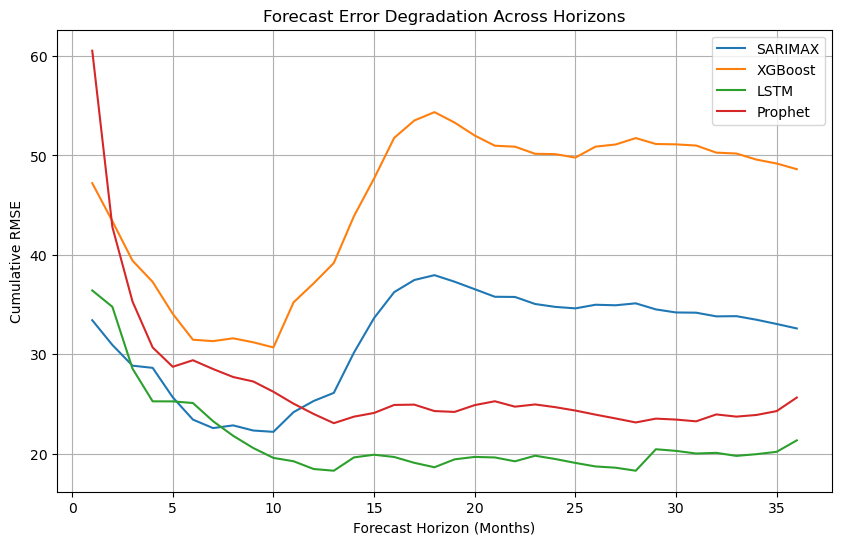

Saved: datasets/outputs\04_horizon_degradation_plot.png


In [46]:
# ==========================================
# SAVE HORIZON DEGRADATION PLOT
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(horizon_df["Horizon"], horizon_df["SARIMAX"], label="SARIMAX")
plt.plot(horizon_df["Horizon"], horizon_df["XGBoost"], label="XGBoost")
plt.plot(horizon_df["Horizon"], horizon_df["LSTM"], label="LSTM")
plt.plot(horizon_df["Horizon"], horizon_df["Prophet"], label="Prophet")

plt.xlabel("Forecast Horizon (Months)")
plt.ylabel("Cumulative RMSE")
plt.title("Forecast Error Degradation Across Horizons")
plt.legend()
plt.grid(True)

plot_path = os.path.join(OUT_DIR, "04_horizon_degradation_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", plot_path)

## 38. Export of Regime-Based Performance Comparison

This section generates and exports a comparative performance table across structural regimes.

The objective is to evaluate how forecasting accuracy changes between:

- Early post-break period (2010–2013)
- Recent evaluation period (2021–2024)

---

### Structure of the Comparison Table

The exported table contains:

- Model name  
- RMSE for 2010–2013 (Regime 1)  
- RMSE for 2021–2024 (Recent evaluation period)

This structure allows direct comparison of model robustness across different structural phases of renewable energy growth.

---

### Analytical Purpose

By comparing regime-specific RMSE values, the analysis assesses:

- Model sensitivity to structural transitions
- Stability across different market phases
- Adaptability to accelerated renewable expansion
- Consistency of forecasting performance over time

If performance varies substantially between regimes, it indicates:

- Structural non-stationarity
- Changing growth dynamics
- Potential need for adaptive modeling strategies

---

### Export and Documentation

The table is saved as:

    05_regime_comparison.csv

This ensures:

- Transparent reporting of regime-based results
- Reproducibility of structural robustness analysis
- Easy integration into thesis tables and appendices

---

### Contribution to the Study

Regime-based performance comparison strengthens the forecasting framework by:

- Linking predictive accuracy to structural market conditions
- Moving beyond aggregate metrics
- Providing deeper insight into long-term model robustness

This step reinforces the methodological rigor of the thesis by explicitly evaluating forecasting stability under structural change.

In [47]:
# ==========================================
# EXPORT REGIME COMPARISON TABLE
# ==========================================

regime_df = pd.DataFrame({
    "Model": ["SARIMAX", "LSTM"],
    "RMSE_2010_2013": [rmse_sarimax_reg1, rmse_lstm_reg1],
    "RMSE_2021_2024": [
        np.sqrt(np.mean(e_sarimax**2)),
        np.sqrt(np.mean(e_lstm**2))
    ]
})

regime_path = os.path.join(OUT_DIR, "05_regime_comparison.csv")
regime_df.to_csv(regime_path, index=False)

print("Saved:", regime_path)
regime_df

Saved: datasets/outputs\05_regime_comparison.csv


,Model,RMSE_2010_2013,RMSE_2021_2024
0,SARIMAX,35.801437,32.602586
1,LSTM,25.277428,21.347268


## 39. Export of LSTM Learning Curve

This section saves the LSTM training and validation loss curves as a high-resolution figure for documentation and analysis.

Learning curves are an essential diagnostic tool in deep learning, providing insight into model convergence and generalization behavior.

---

### Purpose of the Learning Curve

The plotted curves display:

- Training Loss → Model error on the training dataset  
- Validation Loss → Model error on the validation subset  

By examining both curves, we can assess:

- Convergence stability  
- Overfitting risk  
- Underfitting behavior  
- Effectiveness of early stopping  

---

### Interpretation Guidelines

- If both curves decrease and stabilize → Proper convergence  
- If training loss decreases but validation loss increases → Overfitting  
- If both remain high → Underfitting  

The use of early stopping ensures that the model retains the best-performing weights.

---

### Export and Documentation

The figure is saved as:

    06_lstm_learning_curve.png

High-resolution output (300 DPI) ensures:

- Publication-quality graphics  
- Direct inclusion in the thesis  
- Transparent reporting of training dynamics  

---

### Contribution to Methodological Rigor

Including and exporting the learning curve strengthens the thesis by:

- Demonstrating controlled neural network training  
- Providing visual evidence of convergence behavior  
- Supporting claims of model robustness  

This ensures that the LSTM model is not only accurate but also properly trained and validated.

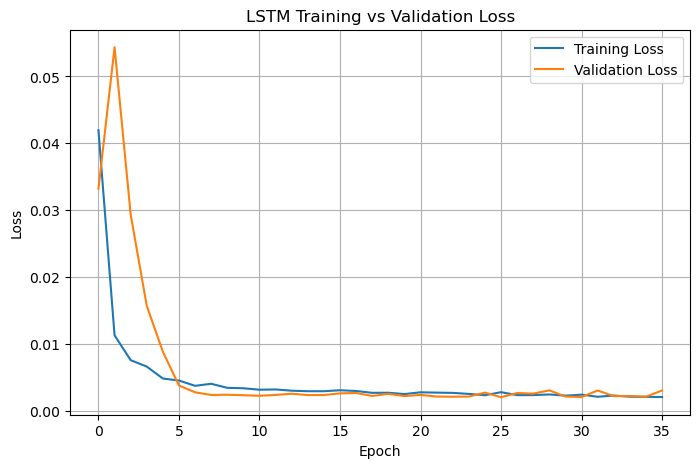

Saved: datasets/outputs\06_lstm_learning_curve.png


In [48]:
# ==========================================
# SAVE LSTM LEARNING CURVE
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')

if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)

lc_path = os.path.join(OUT_DIR, "06_lstm_learning_curve.png")
plt.savefig(lc_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", lc_path)

# Conclusion

This study investigated which forecasting models provide the most reliable long-term predictions of renewable energy consumption using monthly time-series data. The analysis compared four model classes: a classical statistical model (SARIMAX), a decomposition-based model (Prophet), a machine learning algorithm (XGBoost), and a deep learning architecture (LSTM). The models were evaluated using a consistent out-of-sample forecasting framework with a 36-month recursive forecast horizon.

The empirical results show that the **LSTM model achieved the highest predictive accuracy** across all evaluation metrics, including RMSE, MAE, MAPE, SMAPE, and R². Horizon-wise analysis further demonstrated that LSTM maintained comparatively low forecast error growth across the full forecasting horizon. Statistical validation using the **Diebold–Mariano test** confirmed that the predictive performance differences between LSTM and classical models were statistically significant.

Although deep learning produced the most accurate forecasts, the results also reveal important **trade-offs between accuracy and interpretability**. Classical statistical models such as SARIMAX produced smoother forecast trajectories and offer analytical prediction intervals, which enhance interpretability and uncertainty communication. Similarly, Prophet demonstrated improved adaptability to structural trend changes due to its piecewise linear trend formulation.

From a theoretical perspective, the findings contribute to the ongoing debate regarding **model complexity and forecasting performance**. While forecasting competitions often suggest that increased model complexity does not necessarily lead to superior results, the present analysis indicates that deep learning models can outperform classical approaches even with moderately sized monthly datasets when appropriate regularization and model design are applied.

However, the results also highlight that **forecasting model selection is context-dependent**. When the primary objective is maximizing point-forecast accuracy in long-term planning scenarios, deep learning approaches such as LSTM may be preferable. In contrast, when interpretability, structural transparency, and uncertainty estimation are essential—particularly in policy or regulatory contexts—classical statistical models remain valuable tools.

Overall, this study provides a structured comparison of forecasting models under **long-horizon monthly conditions**, demonstrating that model performance depends on the interaction between data characteristics, structural dynamics, and methodological design. As renewable energy systems continue to expand and evolve, robust long-term forecasting will remain critical for strategic planning and infrastructure development.

Future research should explore **hybrid forecasting architectures, probabilistic forecasting frameworks, regime-switching models, and the integration of exogenous economic or meteorological variables** to further improve the reliability and robustness of renewable energy forecasting models.